# Figure 4: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-18 14:13:13,904][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-18 14:13:14,081][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting, regression, utils
from vr4mice.schema import base_analysis, vr4mice
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.decision import PredictionModel, DecisionPoints, InclusionStatus, ExperimentMember, LabelSet, Label

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
task_type_key = {"set_name": "contrast_white_target",
                 "stage_name": "dual_occlusion"}

In [6]:
sessions_list = list(
                (InclusionStatus * ExperimentMember & {"included": 1} & task_type_key).fetch(
                    "dataset"
                )
            )

len(sessions_list)

44

In [7]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in sessions_list:
    print(d)
    try:
        dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-09_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

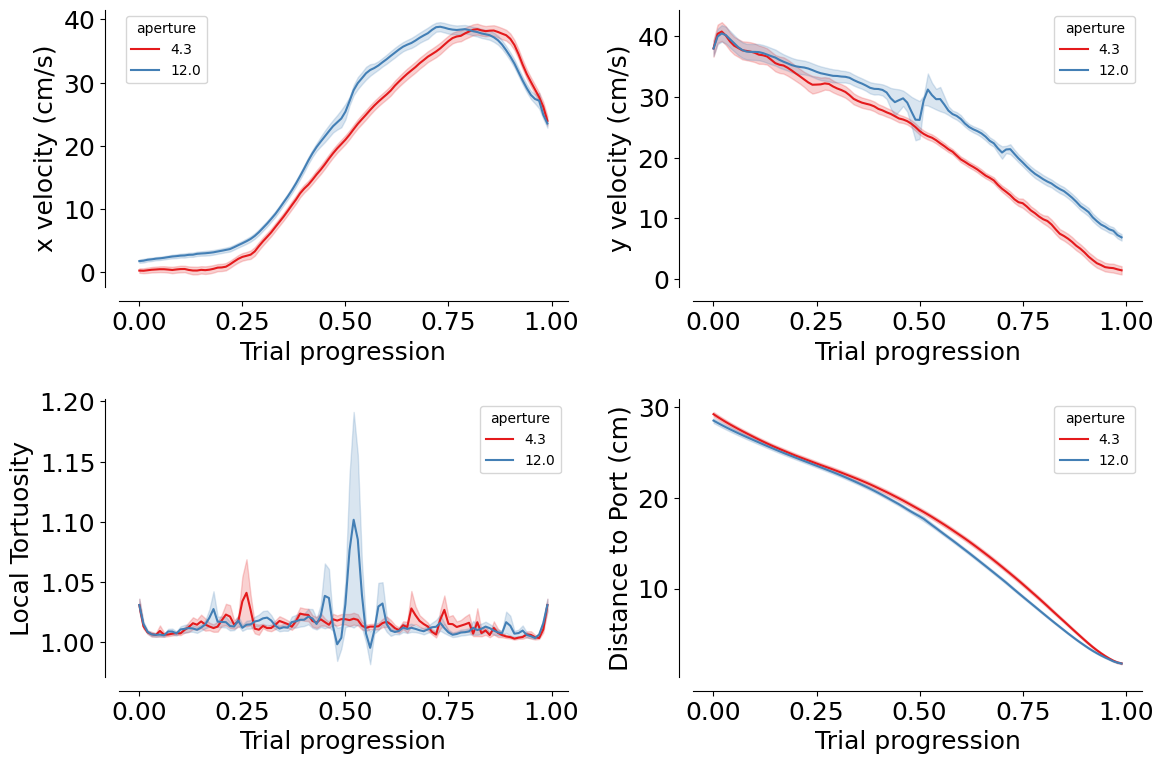

In [9]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else "viridis"
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

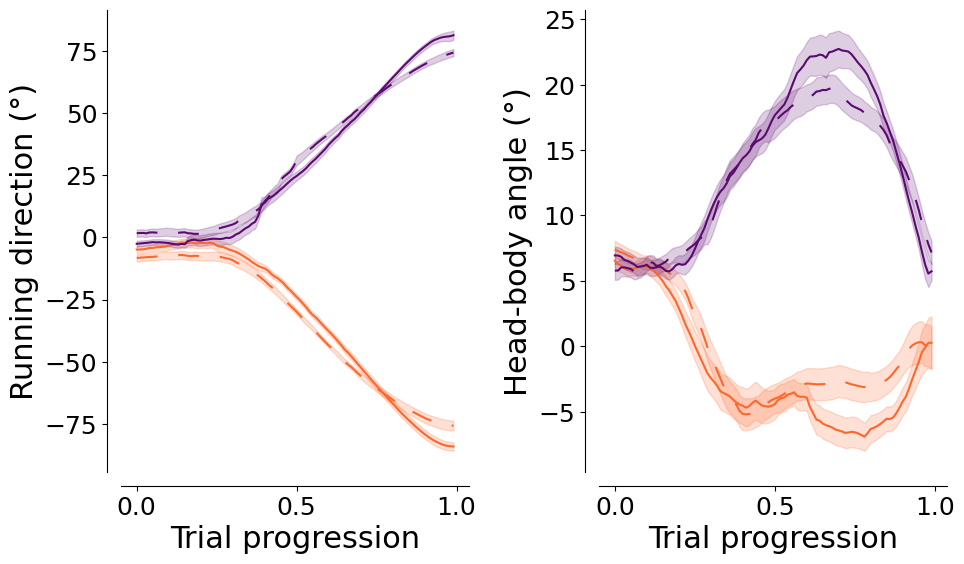

In [10]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction (°)", "Head-body angle (°)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        dashes=dash_styles,
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str, fontsize=22)
    ax[i].set_xlabel("Trial progression", fontsize=22)
    sns.despine(ax=ax[i], offset=10)

    ax[i].legend().remove()
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)
plt.savefig(save_fig_path + "figure4_heading_dir_head_angle.png", bbox_inches="tight", transparent=True, dpi=300)

In [11]:
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]
interpolated_df["heading_dir_flipped"] = interpolated_df.heading_dir * interpolated_df.flip_one_side
interpolated_df["head_angle_flipped"] = interpolated_df.head_angle * interpolated_df.flip_one_side

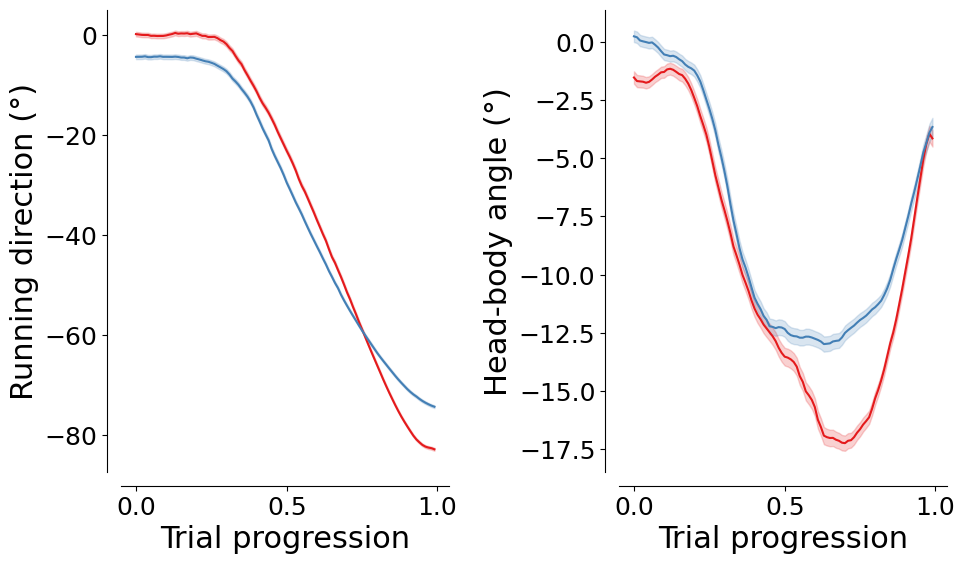

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.flatten()

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="heading_dir_flipped",
    hue="aperture",
    errorbar="se",
    palette=plotting.colors_aperture,
    ax=ax[0],
)
ax[0].set_ylabel("Running direction (°)", fontsize=22)
ax[0].set_xlabel("Trial progression", fontsize=22)
sns.despine(ax=ax[0], offset=10)
ax[0].legend([], [], frameon=False)

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="head_angle_flipped",
    hue="aperture",
    errorbar="se",
    palette=plotting.colors_aperture,
    ax=ax[1],
)
ax[1].set_ylabel("Head-body angle (°)", fontsize=22)
ax[1].set_xlabel("Trial progression", fontsize=22)
sns.despine(ax=ax[1], offset=10)
ax[1].legend([], [], frameon=False)

plt.tight_layout(pad=2)

In [13]:
print(
    AnovaRM(
        data=interpolated_df.groupby(
            ["dataset", "aperture", "trial_length"], as_index=False
        ).mean(numeric_only=True),
        depvar="heading_dir_flipped",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

print(
    AnovaRM(
        data=interpolated_df.groupby(
            ["dataset", "aperture", "trial_length"], as_index=False
        ).mean(numeric_only=True),
        depvar="head_angle_flipped",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                         Anova
                       F Value   Num DF   Den DF  Pr > F
--------------------------------------------------------
aperture                17.1722  1.0000   43.0000 0.0002
trial_length          1235.8944 99.0000 4257.0000 0.0000
aperture:trial_length   22.6590 99.0000 4257.0000 0.0000

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              18.3209  1.0000   43.0000 0.0001
trial_length          91.3852 99.0000 4257.0000 0.0000
aperture:trial_length  3.7924 99.0000 4257.0000 0.0000



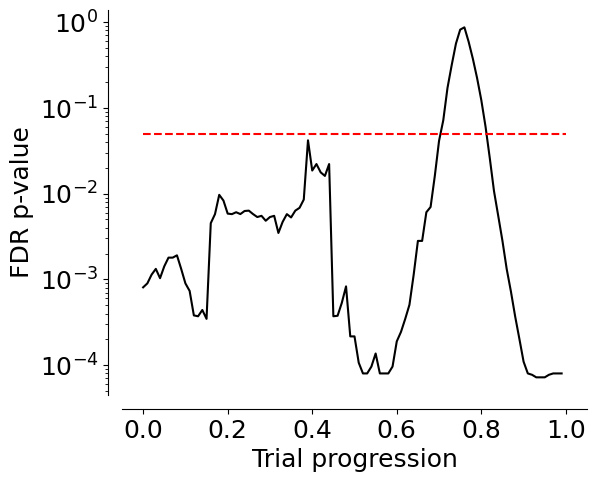

In [14]:
agg = (
    interpolated_df
    .groupby(["dataset", "aperture", "trial_length"], as_index=False)[
        ["heading_dir_flipped", "head_angle_flipped"]
    ]
    .mean(numeric_only=True)
)

aperture_order = sorted(agg.aperture.unique())

p_values = []
for tl in sorted(agg.trial_length.unique()):
    section = agg[agg.trial_length == tl]
    t = ttest_ind(
        section[section.aperture == aperture_order[0]].heading_dir_flipped,
        section[section.aperture == aperture_order[1]].heading_dir_flipped,
    )
    p_values.append({"segment": tl, "p_value": t.pvalue})

p_value_df = pd.DataFrame(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure4_heading_dir_p_values.svg", bbox_inches="tight", transparent=True)

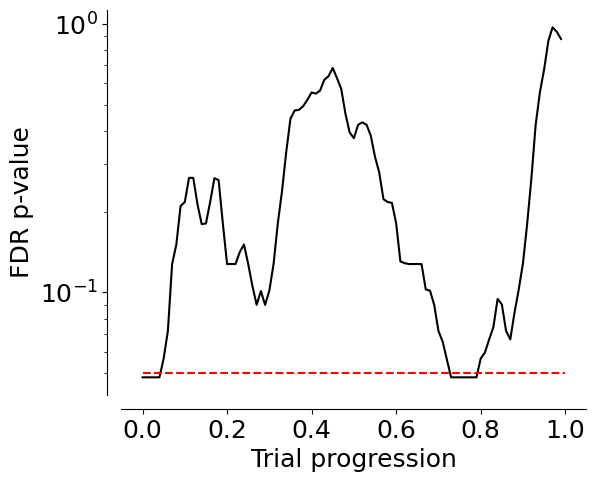

In [15]:
aperture_order = sorted(agg.aperture.unique())
p_values = []
for tl in sorted(agg.trial_length.unique()):
    section = agg[agg.trial_length == tl]
    t = ttest_ind(
        section[section.aperture == aperture_order[0]].head_angle_flipped,
        section[section.aperture == aperture_order[1]].head_angle_flipped,
    )
    p_values.append({"segment": tl, "p_value": t.pvalue})

p_value_df = pd.DataFrame(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure4_head_angle_p_values.svg", bbox_inches="tight", transparent=True)

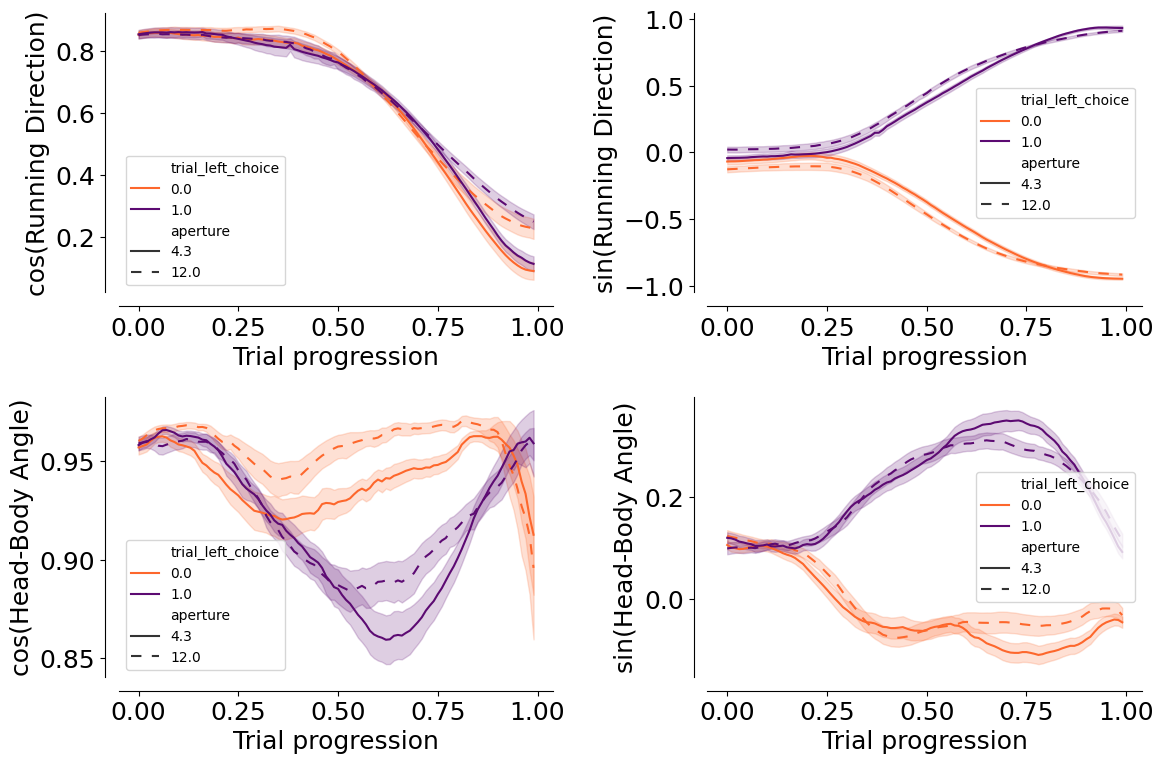

In [16]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

## Prediction model

In [17]:
model_key = {"label_set_id": 8, "params_id": 1}

In [18]:
# Coefficients for dual occluder task
coef = (PredictionModel() & model_key & task_type_key).fetch1("coefficients")

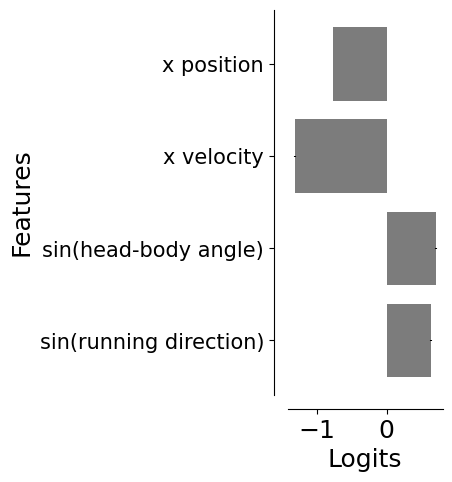

In [19]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "figure4_model_logits.svg", transparent=False)

In [20]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [21]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

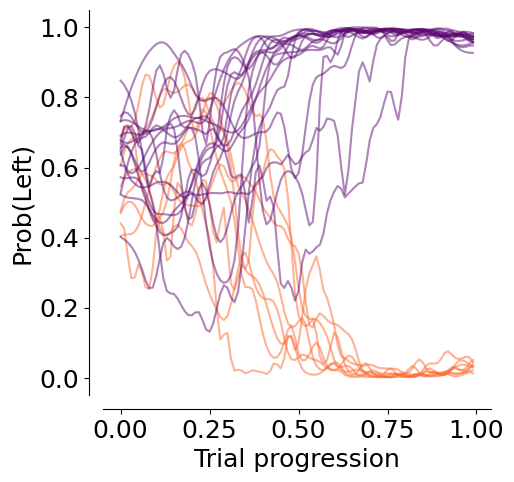

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Kiwi_2024-08-14_1")]

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure4_dynamic_decision_variable.svg",
    transparent=True,
)

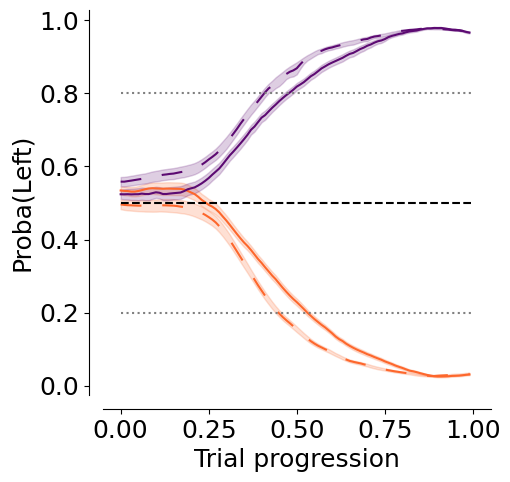

In [23]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se",
    dashes=dash_styles
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.8, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.2, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure4_dynamic_decision_variable_avg.png",
    transparent=True,
    dpi=300,
)

plt.savefig(
    save_fig_path + "figure4_dynamic_decision_variable_avg.svg",
    transparent=True,
)

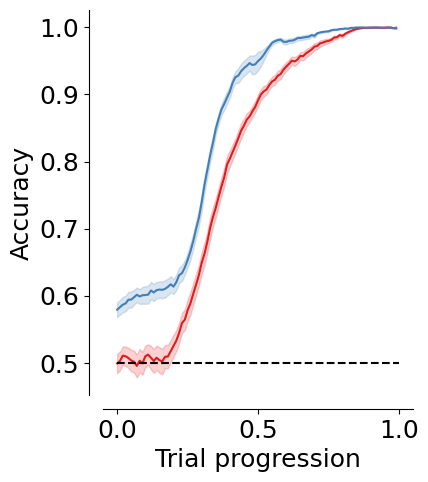

In [24]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure4_model_accuracy.svg", transparent=True
)

In [25]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)

df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                           F Value   Num DF   Den DF  Pr > F
------------------------------------------------------------
aperture                    46.7087  1.0000   43.0000 0.0000
trial_length_bin          1019.1208 49.0000 2107.0000 0.0000
aperture:trial_length_bin   13.7942 49.0000 2107.0000 0.0000



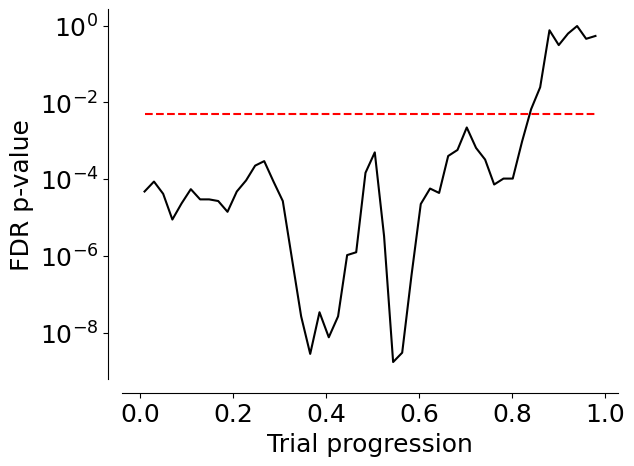

In [26]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].accuracy,
        section[section.aperture == section.aperture.unique()[1]].accuracy,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(
    0.005,
    xmin=p_value_df.segment.min(),
    xmax=p_value_df.segment.max(),
    color="red",
    linestyle="dashed",
)

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure4_model_accuracy_pvalue.svg", transparent=True
)

### Comparison to other models

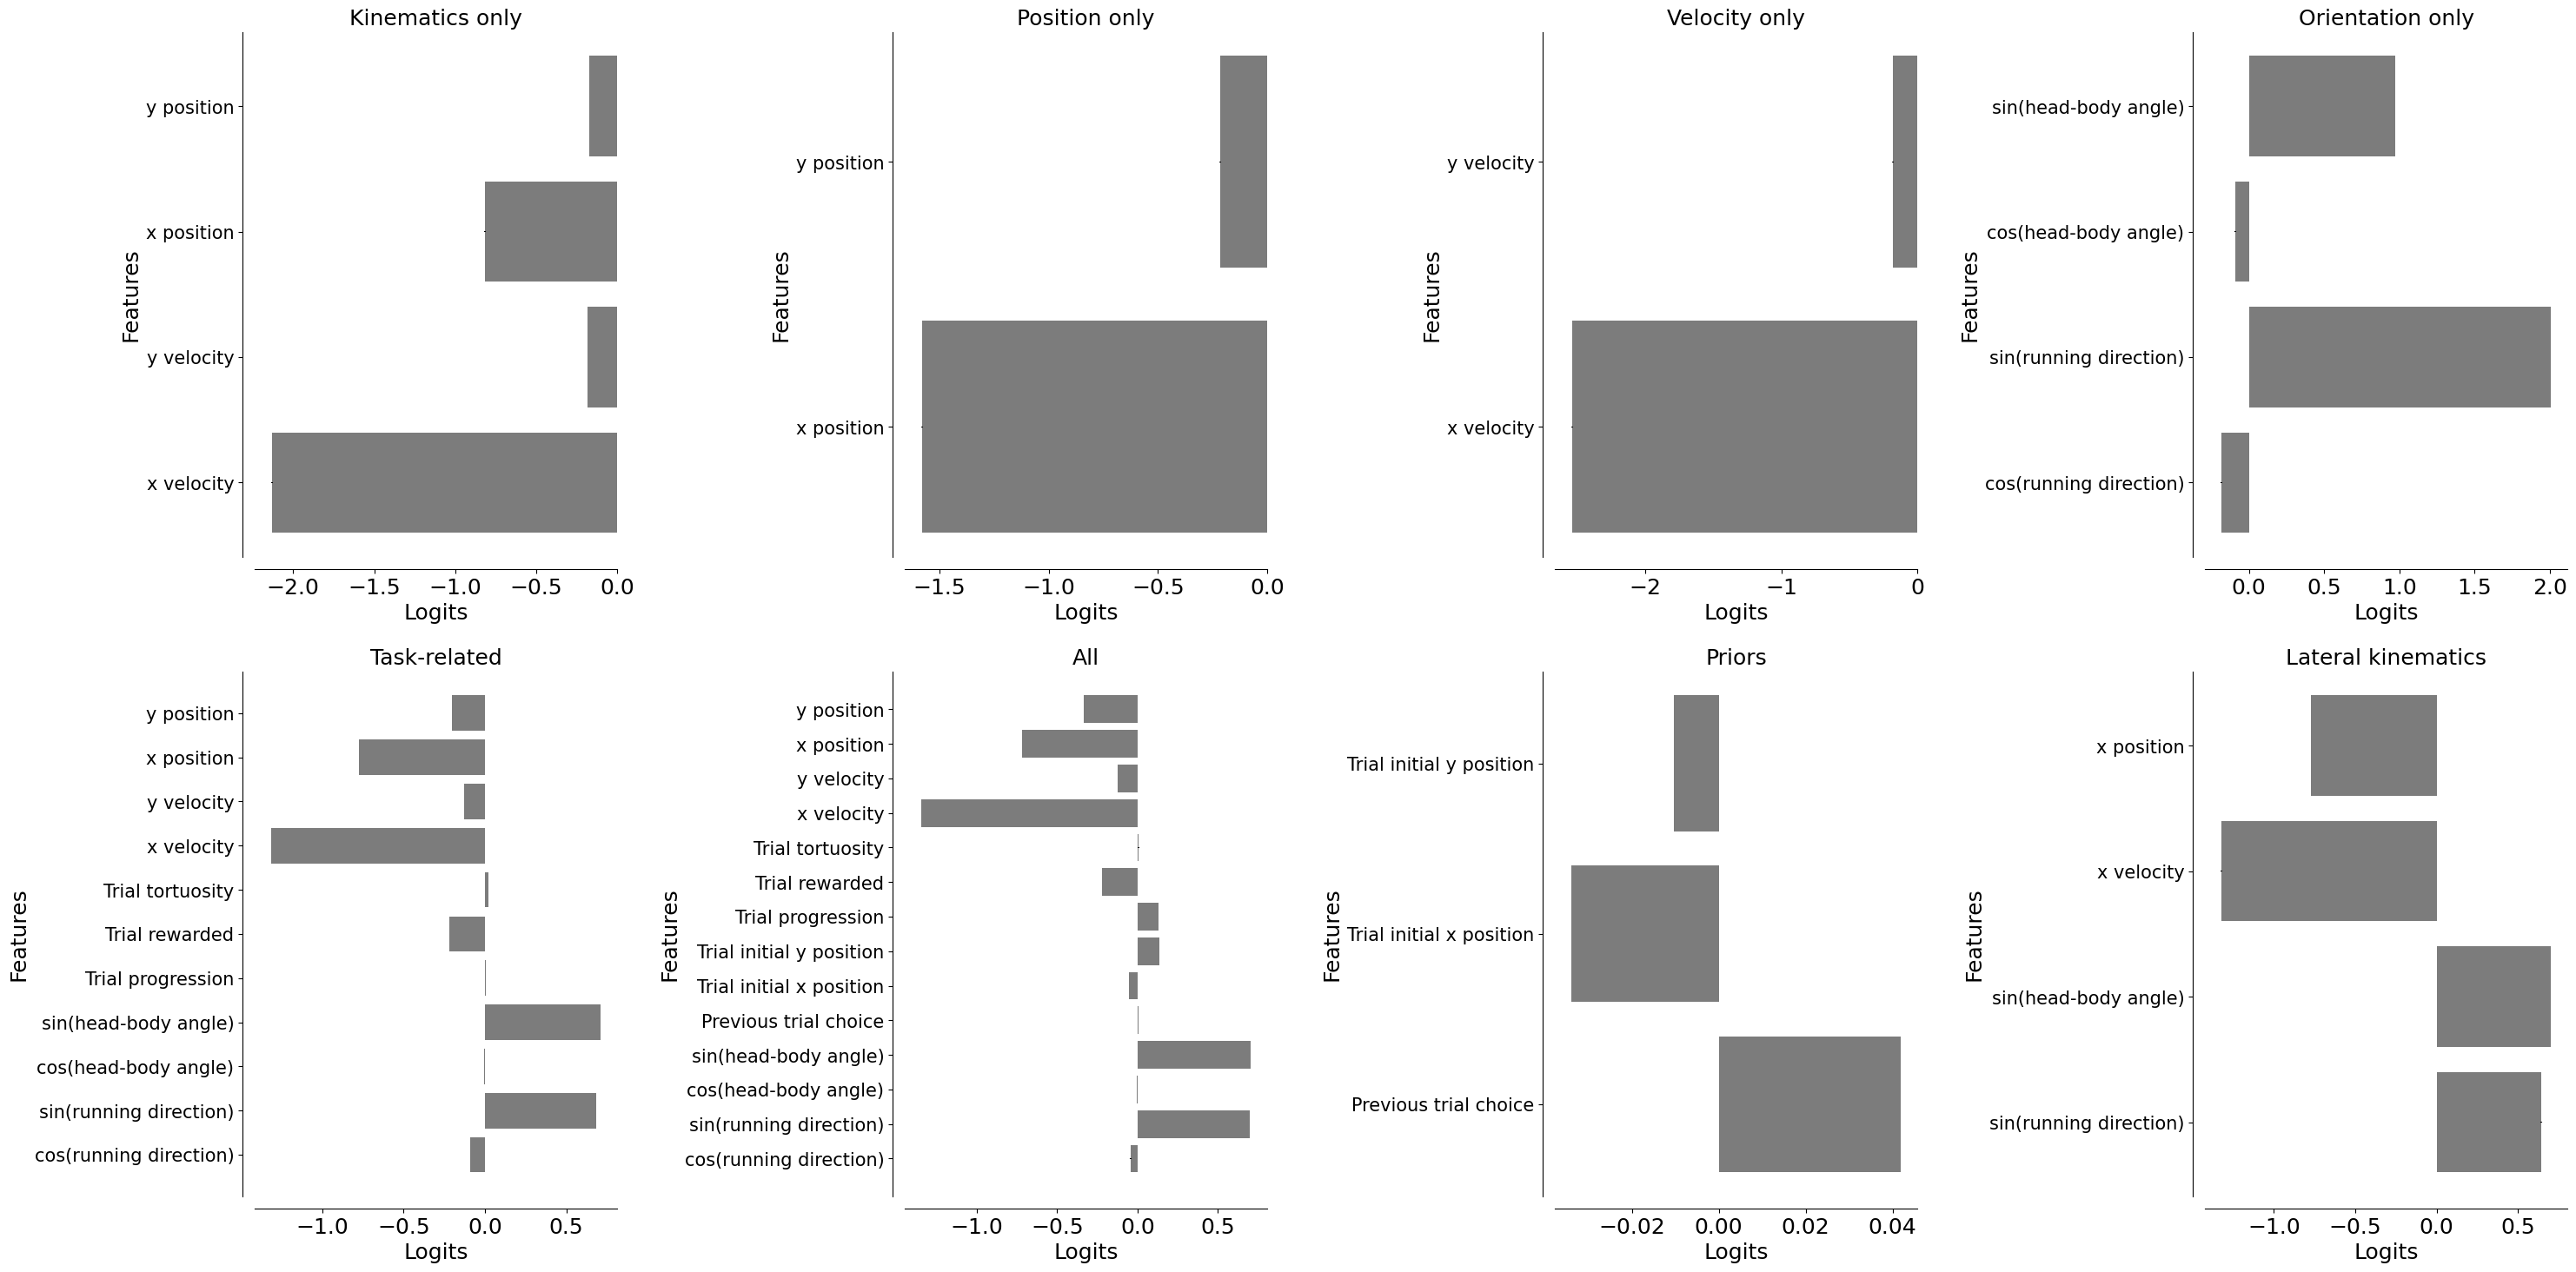

In [27]:
fig, ax = plt.subplots(2, 4, figsize=(30, 15))

for label_set_id, axis in zip(range(1, 9), ax.flatten()):
    model_labels, clean_labels, label_set_name = (
        LabelSet.Member * Label * LabelSet & f"label_set_id='{label_set_id}'").fetch(
            "label_key", "clean_name", "label_set_name")
        
    if "Best Task-related" in label_set_name:
        label_set_name = ["Lateral kinematics" for _ in model_labels]
    
    coef = (PredictionModel() & dict({'label_set_id': label_set_id,
                                      "params_id":1}, **task_type_key)).fetch1("coefficients")
    axis.barh(
        model_labels,
        np.mean(coef[:, 1:], axis=0),
        yerr=stats.sem(coef[:, 1:], axis=0),
        color="#7C7C7C",
    )
    sns.despine(offset=10, ax=axis)
    axis.set_yticks(np.arange(len(model_labels)))
    axis.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
    axis.set_xlabel("Logits")
    axis.set_ylabel("Features")
    axis.set_title(f"{label_set_name[0]}", fontsize=18)
    
plt.tight_layout(pad=2.0)
plt.savefig(save_fig_path + "figure4_all_model_logits.svg", transparent=False)

In [28]:
pred_all = pd.DataFrame((PredictionModel().SessionPrediction() & task_type_key & {"params_id":1}).fetch(as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length", "bic", "trial_left_choice"])
pred_all["bic"] = pred_all["bic"].astype(float)
pred_all["accuracy"] = pred_all["accuracy"].astype(float)

In [29]:
# Define bins and labels
bins = [0, 0.5, 1.0]
labels = ['0.0-0.5', '0.5-1.0']

In [30]:
pred_all['length_interval'] = pd.cut(pred_all['trial_length'], bins=bins, labels=labels, include_lowest=True)
pred_all["coef_var_bic"] = pred_all.groupby(["label_set_id", "trial", "length_interval"])["bic"].transform(lambda x: x.std() / x.mean())

In [31]:
summary_df = pd.merge(pred_all.groupby(["label_set_id", "length_interval"])[["coef_var_bic", 
                                                                             "accuracy", 
                                                                             "bic",]].mean(), 
         pd.DataFrame(LabelSet().fetch()).set_index("label_set_id"), left_index=True, right_index=True)
summary_df["label_set_name"] = summary_df.label_set_name.str.replace("Best Task-related", "Lateral kinematics")
summary_df = summary_df.unstack(level=-1)
summary_df["diff_bic"] = summary_df["bic"]["0.0-0.5"] - summary_df["bic"]["0.5-1.0"]

In [32]:
accuracy_05_10 = summary_df[("accuracy", "0.5-1.0")]
bic_05_10 = summary_df[("bic", "0.5-1.0")]
delta_cv = (summary_df[("coef_var_bic", "0.0-0.5")] - summary_df[("coef_var_bic", "0.5-1.0")])

s_score = (accuracy_05_10 / bic_05_10) * delta_cv
s_score = s_score.replace([np.inf, -np.inf], np.nan)

s_df = pd.DataFrame({
    "label_set_name": summary_df[("label_set_name", "0.0-0.5")],
    "accuracy_0.5-1.0": accuracy_05_10,
    "bic_0.5-1.0": bic_05_10,
    "delta_cv": delta_cv,
    "score": s_score,
}).sort_values("score", ascending=False)

s_df

,label_set_name,accuracy_0.5-1.0,bic_0.5-1.0,delta_cv,score
label_set_id,,,,,
8,Lateral kinematics,0.980977,13.097562,0.198662,1.487930e-02
1,Kinematics only,0.977025,13.396176,0.171673,1.252063e-02
4,Orientation only,0.975087,13.813094,0.174448,1.231452e-02
3,Velocity only,0.967331,9.542332,0.120936,1.225962e-02
5,Task-related,0.981228,29.168729,0.162014,5.450090e-03
6,All,0.980957,36.086370,0.143747,3.907552e-03
7,Priors,0.554292,22.976093,-0.000001,-2.577627e-08
2,Position only,0.935363,11.920947,-0.009005,-7.065973e-04


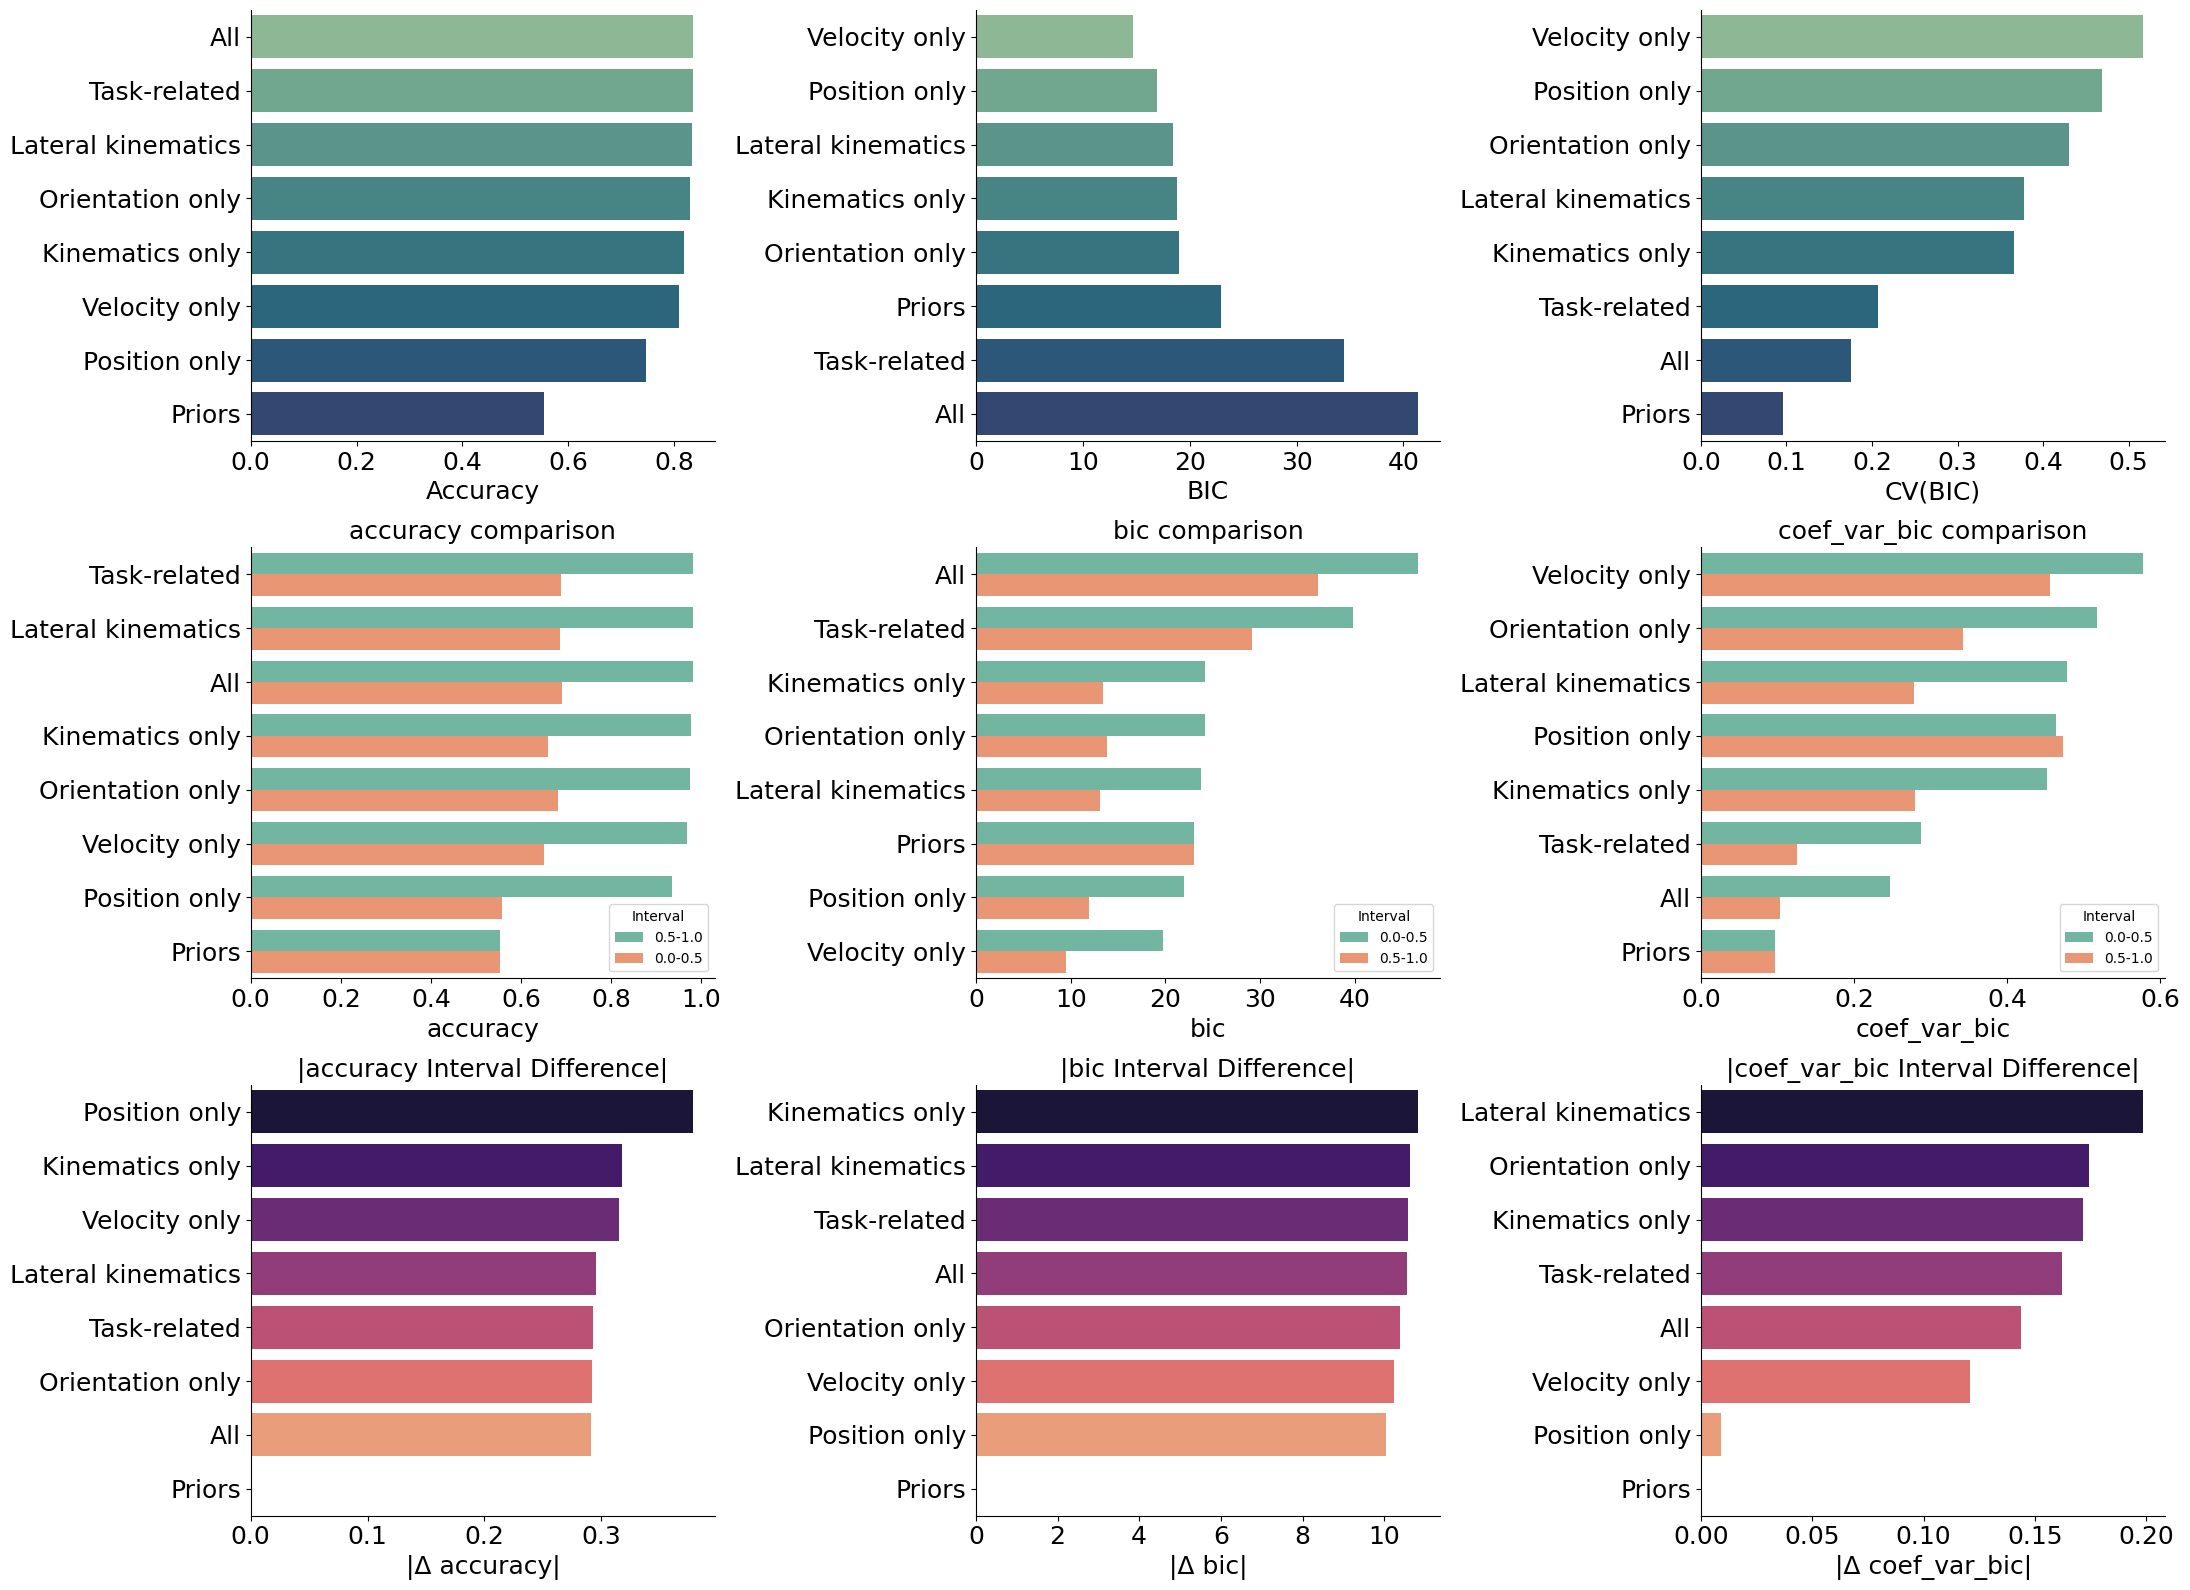

In [33]:
metrics = {"accuracy": "Accuracy", "bic": "BIC", "coef_var_bic": "CV(BIC)"}

fig, axes = plt.subplots(3, 3, figsize=(22, 16))

# Row 1: mean values per metric
for i, (m, m_label) in enumerate(metrics.items()):
    ax = axes[0, i]
    metric_mean = summary_df[m].mean(axis=1)
    temp_df = pd.DataFrame({
        "label": summary_df[("label_set_name", "0.0-0.5")],
        "mean_val": metric_mean,
    }).sort_values("mean_val", ascending=not (m != "bic"))

    sns.barplot(data=temp_df, x="mean_val", y="label", ax=ax, palette="crest")
    ax.set_xlabel(m_label)
    ax.set_ylabel("")

# Row 2: interval comparison per metric
for i, metric in enumerate(metrics):
    ax = axes[1, i]
    plot_df = summary_df[metric].copy()
    plot_df["label"] = summary_df[("label_set_name", "0.0-0.5")]
    melted = plot_df.melt(id_vars="label", var_name="Interval", value_name=metric)
    melted = melted.sort_values(by=metric, ascending=False)

    sns.barplot(data=melted, x=metric, y="label", hue="Interval", ax=ax, palette="Set2")
    ax.set_title(f"{metric} comparison")
    ax.set_ylabel("")

# Row 3: absolute interval differences per metric
for i, metric in enumerate(metrics):
    ax = axes[2, i]
    diff_series = (summary_df[(metric, "0.0-0.5")] - summary_df[(metric, "0.5-1.0")]).abs()
    plot_df = pd.DataFrame({
        "label": summary_df[("label_set_name", "0.0-0.5")],
        "delta_metric": diff_series,
    }).sort_values("delta_metric", ascending=False)

    sns.barplot(data=plot_df, x="delta_metric", y="label", ax=ax, palette="magma")
    ax.set_title(f"|{metric} Interval Difference|")
    ax.set_ylabel("")
    ax.set_xlabel(f"|Δ {metric}|")

plt.tight_layout()
plt.show()

## Decision point analysis

### Select the threshold based on change in kinematics before -- after

In [34]:
session_to_plot = "Pheasant_2024-08-15_2"

In [35]:
threshold_values = [0.1, 0.2, 0.3, 0.4, 0.5]
threshold_keys = [{'threshold_uncertainty': val} for val in threshold_values]

In [36]:
all_decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key).fetch(as_dict=True))
all_decision_points = all_decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
all_decision_points["mouse_name"] = all_decision_points.dataset.str.split("_").str[0]

In [37]:
all_decision_points.dropna(subset=["y"], inplace=True)
all_decision_points["distance_to_screen"] = np.abs(all_decision_points["y"] - 27)

In [38]:
# Compare metrics before vs after to select the best threshold for defining decision points
decision_window = 10
eval_df_norm = regression.select_threshold(all_decision_points, interpolated_df, decision_window=decision_window)

Analyzing decision points with threshold_uncertainty 0.5 (normalized)...
Analyzing decision points with threshold_uncertainty 0.4 (normalized)...
Analyzing decision points with threshold_uncertainty 0.3 (normalized)...
Analyzing decision points with threshold_uncertainty 0.2 (normalized)...
Analyzing decision points with threshold_uncertainty 0.1 (normalized)...


In [39]:
eval_df_norm.groupby("threshold").mean(numeric_only=True)

,jump_score_norm,jump_score,n_trials,z_vx,z_vy,z_ang,z_dir,vx_delta,vy_delta,ang_delta,dir_delta,t_stat,p_value,p_value_fisher
threshold,,,,,,,,,,,,,,
0.1,1.531768,54.532648,186.931818,0.951522,-0.128554,0.126900,0.324792,17.312171,-5.466236,12.752202,19.002038,7.387071,0.006511,0.000000e+00
0.2,1.800123,57.531004,193.545455,1.102310,-0.106340,0.274154,0.317319,19.125674,-5.155241,14.492491,18.757598,8.529365,0.012171,0.000000e+00
0.3,1.735432,56.457913,187.159091,1.032381,-0.077208,0.387021,0.238822,18.156091,-4.828324,15.756057,17.717442,7.765701,0.006176,0.000000e+00
0.4,1.618261,54.782525,174.022727,0.905611,-0.034440,0.522338,0.155872,16.519386,-4.262624,17.299423,16.701092,6.718919,0.007727,0.000000e+00
0.5,1.413518,52.112395,161.454545,0.742525,0.021169,0.622557,0.069605,14.425168,-3.431888,18.484782,15.770557,5.536470,0.011670,4.159268e-264


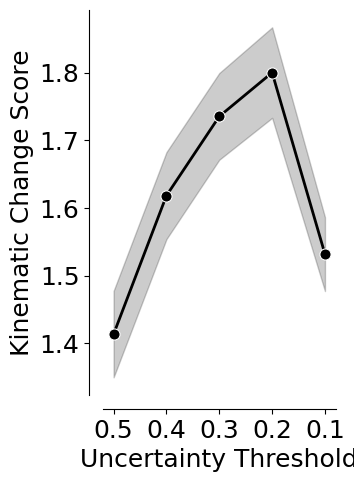

In [40]:
fig, ax1 = plt.subplots(figsize=(3, 5))

sns.lineplot(data=eval_df_norm.sort_values("threshold", ascending=False), 
             x='threshold', 
             y='jump_score_norm', 
             marker='o', 
             errorbar="se",
             linewidth=2, 
             markersize=8, 
             ax=ax1, 
             color="black")

ax1.set_xlabel('Uncertainty Threshold', fontsize=18)
ax1.set_ylabel('Kinematic Change Score', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=18)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_decision_point_threshold_selection.svg", transparent=True, bbox_inches="tight")

In [41]:
all_decision_points.dropna(subset=["y"], inplace=True)
all_decision_points["distance_to_screen"] = np.abs(all_decision_points["y"] - 27)

In [42]:
filtered_df = all_decision_points[all_decision_points["aperture"].isin([4.3, 12.0])]
grouped = filtered_df.groupby(["mouse_name", "dataset", "threshold_uncertainty", "aperture"])["distance_to_screen"].mean().unstack("aperture")

grouped["diff"] = grouped[12.0] - grouped[4.3]
result_df = grouped.reset_index()

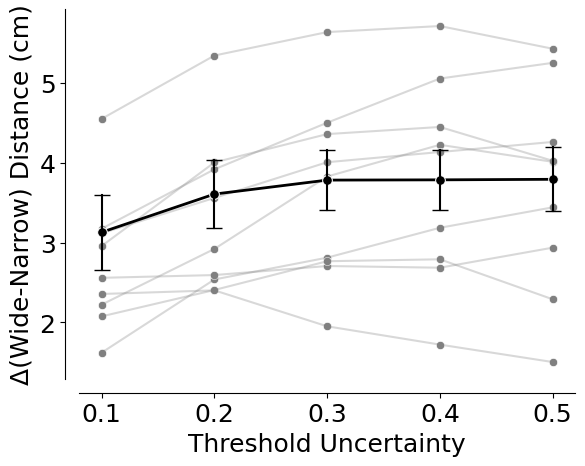

In [43]:
# Average sessions for each mouse first
mouse_averages = result_df.groupby(["mouse_name", "threshold_uncertainty"], as_index=False)["diff"].mean()
session_averages = result_df.groupby(["threshold_uncertainty"], as_index=False)["diff"].mean()

# Plot individual mouse lines (gray)
sns.lineplot(
    data=mouse_averages[mouse_averages.mouse_name != "J731"], 
    x="threshold_uncertainty", 
    y="diff", 
    units="mouse_name", 
    estimator=None, 
    color="gray", 
    alpha=0.3
)

# Plot individual mouse points
sns.scatterplot(
    data=mouse_averages[mouse_averages.mouse_name != "J731"],
    x="threshold_uncertainty", 
    y="diff", 
    color="grey",
    
)

# Plot global average + SEM (black)
sns.lineplot(
    data=mouse_averages, 
    x="threshold_uncertainty", 
    y="diff", 
    errorbar="se", 
    color="black", 
    linewidth=2, 
    marker="o",
    markersize=7,
    err_style="bars", 
    err_kws={'capsize': 6}
)

plt.ylabel("Δ(Wide-Narrow) Distance (cm)")
plt.xlabel("Threshold Uncertainty")
sns.despine(offset=10)

### Threshold selected: 0.2, the rest is with that threshold

In [44]:
decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]

In [45]:
decision_points["distance_to_screen"] = np.abs(decision_points["y"].astype(float) - 27)

Decision Time: 0.37


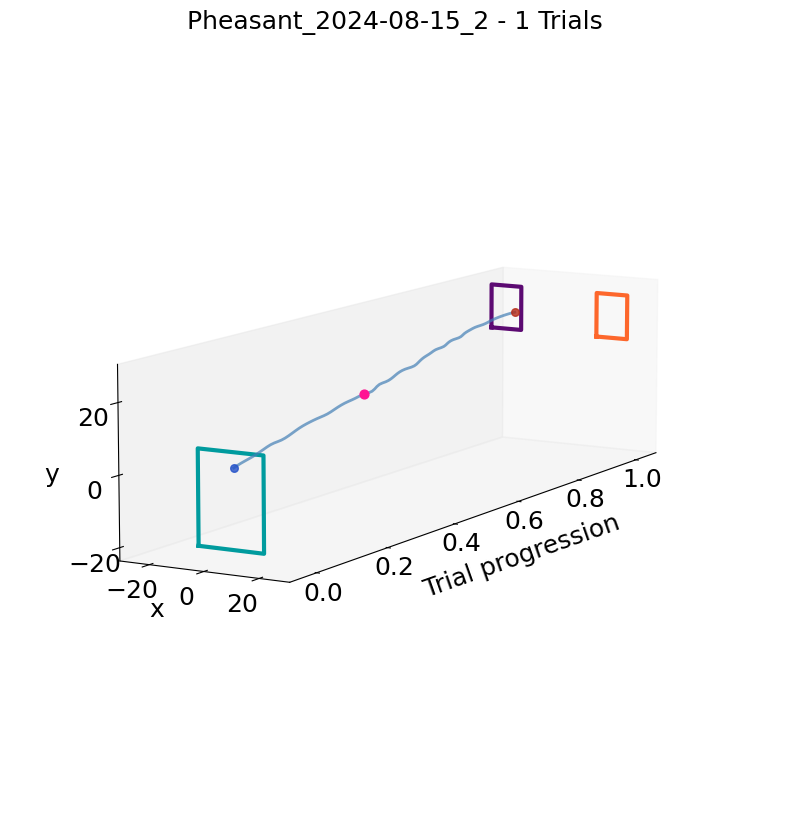

<Figure size 640x480 with 0 Axes>

In [46]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == session_to_plot],
    box_df=box_df,
    trial_ids=[69],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == session_to_plot]
)

plt.show()
plt.savefig(save_fig_path + "figure4_3d_trajectory_wide.svg", bbox_inches="tight", transparent=True)

Decision Time: 0.45


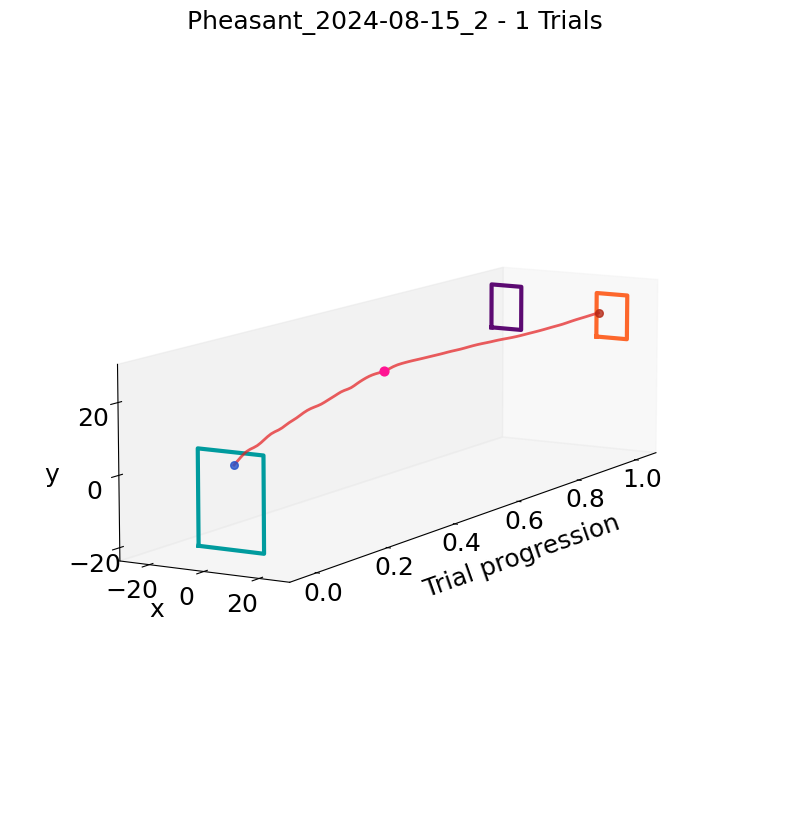

<Figure size 640x480 with 0 Axes>

In [47]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == session_to_plot],
    box_df=box_df,
    trial_ids=[125],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == session_to_plot]
)

plt.show()
plt.savefig(save_fig_path + "figure4_3d_trajectory_narrow.svg", bbox_inches="tight", transparent=True)

In [48]:
with open("notebooks/Paper_figures/info_matrix_52x52x31_124.npy", "rb") as file:
    info_matrix_narrow = np.rot90(np.load(file), k=1)
with open("notebooks/Paper_figures/info_matrix_52x52x31_346.npy", "rb") as file:
    info_matrix_wide = np.rot90(np.load(file), k=1)

info_matrices = [info_matrix_narrow, info_matrix_wide]

# normalize info matrices to max 1
info_matrices = [im / im.max() for im in info_matrices]

/tmp/ipykernel_1603715/201383483.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap("PuOr")


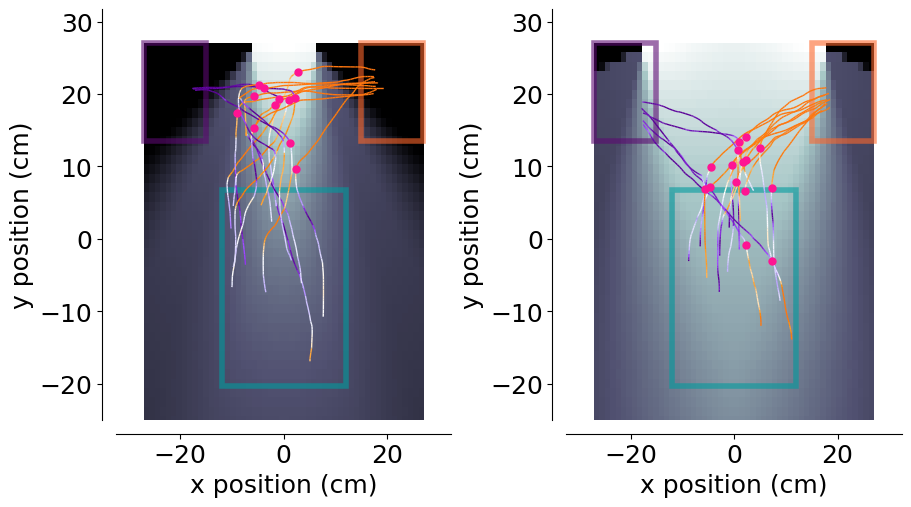

<Figure size 640x480 with 0 Axes>

In [49]:
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(9, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=2):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(df_model.aperture.unique()[::-1]):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )
    
    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()

    im = ax[i].imshow(info_matrices[i], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(xlim)
    ax[i].set_ylim(ylim)
    ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
    sns.despine(offset=10, ax=ax[i])

plt.show()
plt.savefig(
    save_fig_path + "figure4_decision_points_trajectories_bright.svg",
    transparent=True,
)

### Velocity aligned on the decision point

In [50]:
def get_info_at_position(info_matrix, position):
    # Assuming info_matrix is a 2D numpy array and position is a tuple (x, y)
    x, y = position
    # Convert position to matrix indices
    x_idx = int(x + 27)
    y_idx = int(y + 27)
    
    # but the matrix is 52x42 so the positions need to be scaled down
    x_idx_norm = int(x_idx * (51 / 54))
    y_idx_norm = int(y_idx * (41 / 54))
    
    y_idx_norm = info_matrix.shape[0] - 1 - y_idx_norm
    return info_matrix[y_idx_norm, x_idx_norm]  # Note: y comes first in matrix indexing

In [51]:
# Compute information for each timepoint in interpolated_df
interpolated_df["info_gain"] = interpolated_df.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [52]:
decision_points.dropna(subset=["x", "y"], inplace=True)
decision_points["info_gain"] = decision_points.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [53]:
# Convert to sec
interpolated_df["time_in_sec"] = interpolated_df["trial_length"] * interpolated_df["trial_duration"]

durations = interpolated_df[["dataset", "trial", "trial_duration"]].drop_duplicates()
decision_points = decision_points.merge(durations, on=["dataset", "trial"], how="left")
decision_points["time_in_sec"] = decision_points["trial_length"] * decision_points["trial_duration"]

In [54]:
interpolated_df["distance_to_screen"] = np.abs(interpolated_df["y"] - 27)

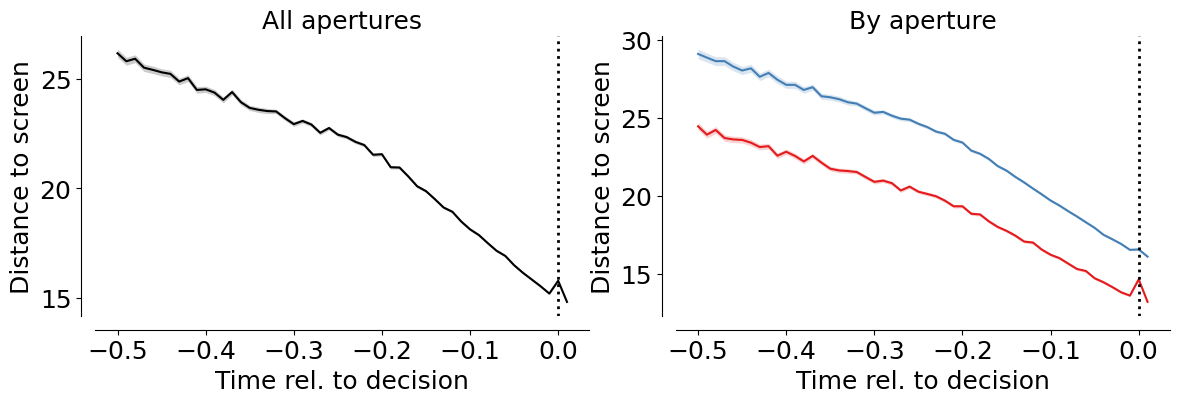

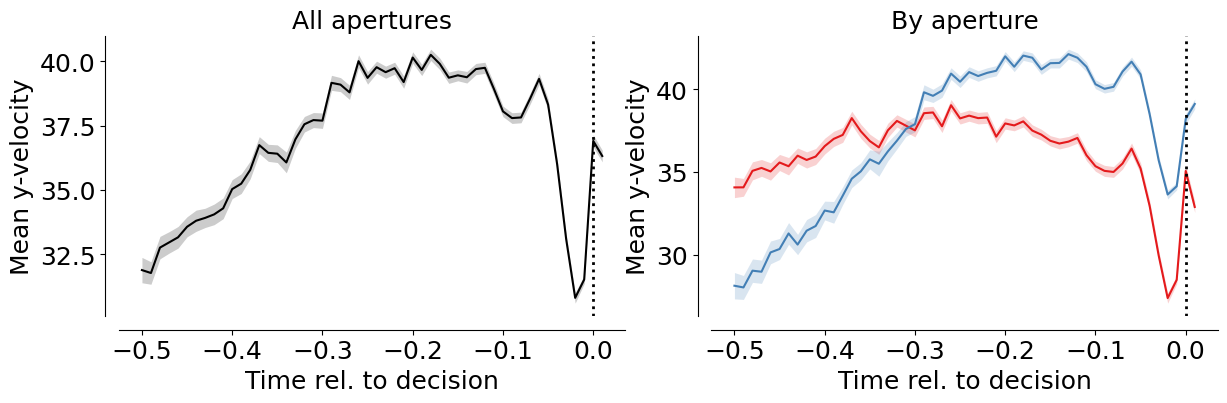

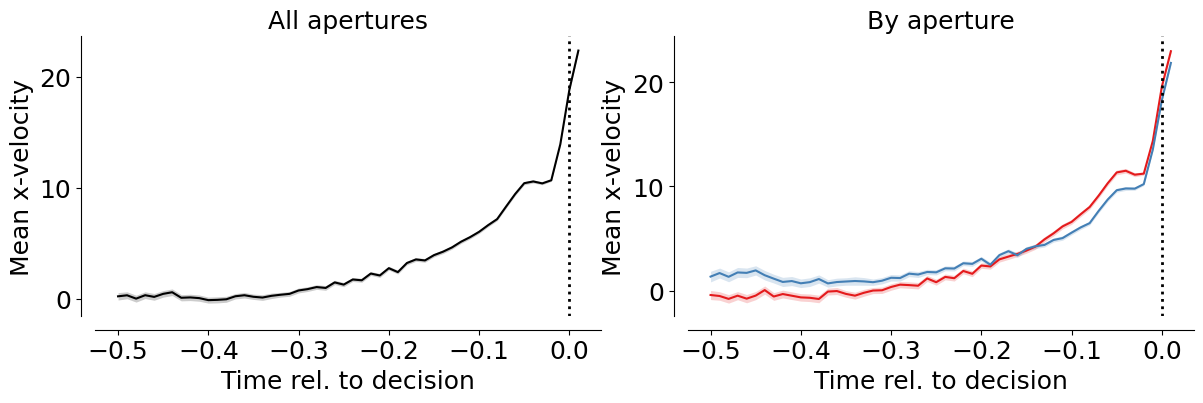

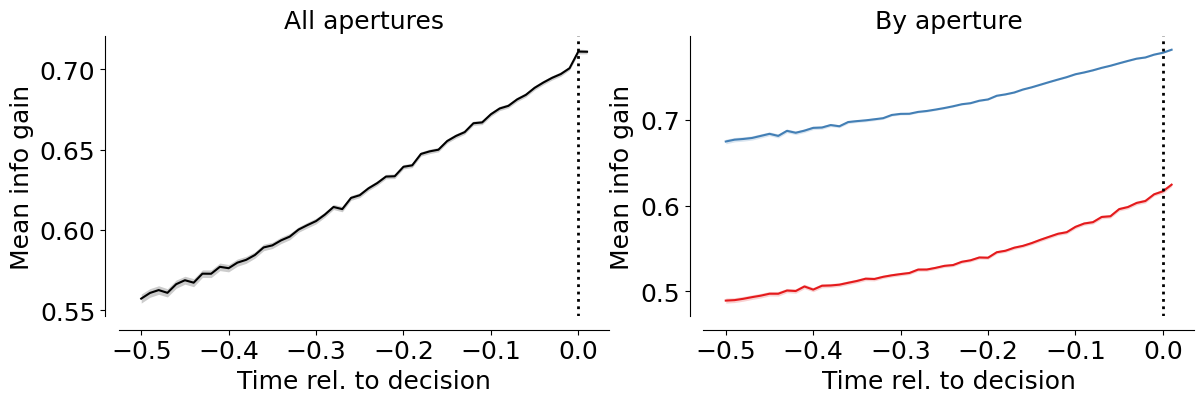

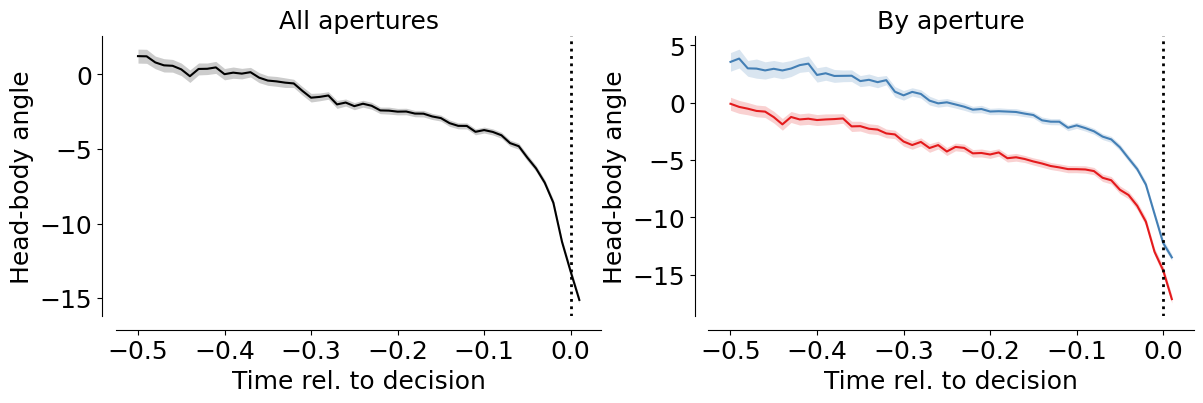

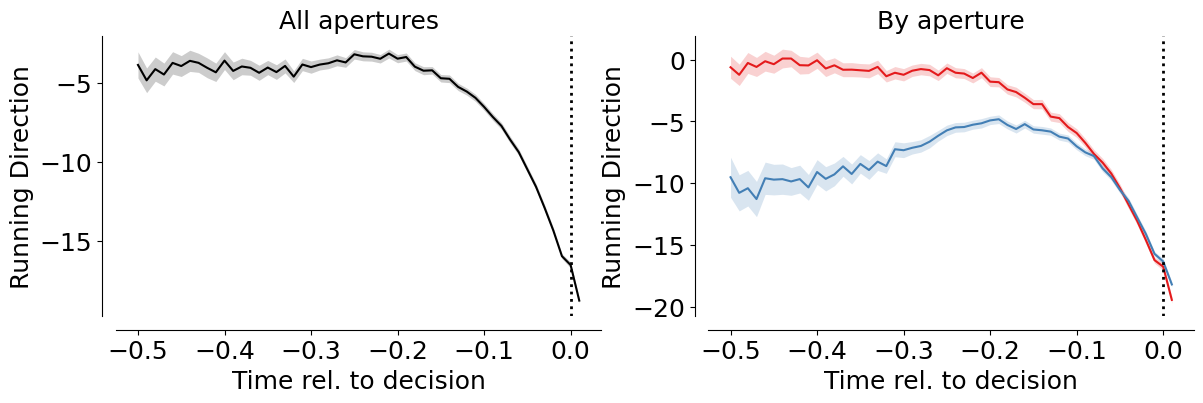

In [55]:
# Average velocity/info_gain around decision point
bin_size = 0.01
pre_window = 0.5
post_window = 0.02

dp_all = decision_points[["dataset", "aperture", "trial", "time_in_sec"]].rename(
    columns={"time_in_sec": "decision_tl"}
)

df_all = interpolated_df.merge(
    dp_all,
    on=["dataset", "aperture", "trial"],
    how="inner",
).copy()

df_all["t_rel"] = df_all["time_in_sec"] - df_all["decision_tl"]
df_all = df_all[(df_all.t_rel >= -pre_window) & (df_all.t_rel <= post_window)]

bins = np.arange(-pre_window, post_window + bin_size, bin_size)
df_all["t_bin"] = pd.cut(df_all.t_rel, bins=bins, labels=bins[:-1])

def _bin_mean_sem(frame, value_col):
    binned = (
        frame.groupby(["aperture", "t_bin"])[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    binned["t_bin"] = binned["t_bin"].astype(float)
    return binned

metrics = [
    {
        "col": "distance_to_screen",
        "ylabel": "Distance to screen",
        "file": "figure4_distance_to_screen_around_decision.svg",
    },
    {
        "col": "velocity_y",
        "ylabel": "Mean y-velocity",
        "file": "figure4_velocity_around_decision.svg",
    },
    {
        "col": "velocity_x_fliped",
        "ylabel": "Mean x-velocity",
        "file": "figure4_velocity_x_around_decision.svg",
    },
    {
        "col": "info_gain",
        "ylabel": "Mean info gain",
        "file": "figure4_info_gain_around_decision.svg",
    },
    {
        "col": "head_angle_flipped",
        "ylabel": "Head-body angle",
        "file": "figure4_head_angle_around_decision.svg"
    },
    {
        "col": "heading_dir_flipped",
        "ylabel": "Running Direction",
        "file": "figure4_heading_dir_around_decision.svg"
    }
]

binned_by_metric = {}
for metric in metrics:
    value_col = metric["col"]
    binned = _bin_mean_sem(df_all, value_col)
    binned_by_metric[value_col] = binned
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # Overall
    overall = (
        df_all.groupby("t_bin")[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    overall["t_bin"] = overall["t_bin"].astype(float)
    axes[0].plot(overall.t_bin, overall["mean"], color="black", linewidth=1.5)
    axes[0].fill_between(
        overall.t_bin,
        overall["mean"] - overall["sem"],
        overall["mean"] + overall["sem"],
        color="black",
        alpha=0.2,
        linewidth=0,
    )
    axes[0].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[0].set_title("All apertures")
    axes[0].set_ylabel(metric["ylabel"])
    axes[0].set_xlabel("Time rel. to decision")
    sns.despine(ax=axes[0])

    # By aperture
    for idx, ap in enumerate(sorted(df_all.aperture.unique())[:2]):
        ap_df = binned[binned.aperture == ap]
        color = plotting.colors_aperture[idx] if "plotting" in globals() else None
        axes[1].plot(ap_df.t_bin, ap_df["mean"], color=color, linewidth=1.5, label=f"Aperture {ap}")
        axes[1].fill_between(
            ap_df.t_bin,
            ap_df["mean"] - ap_df["sem"],
            ap_df["mean"] + ap_df["sem"],
            color=color,
            alpha=0.2,
            linewidth=0,
        )
    axes[1].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[1].set_title("By aperture")
    axes[1].set_xlabel("Time rel. to decision")
    axes[1].set_ylabel(metric["ylabel"])
    sns.despine(ax=axes[1])

    plt.tight_layout()
    sns.despine(offset=10)
    plt.savefig(save_fig_path + metric["file"])


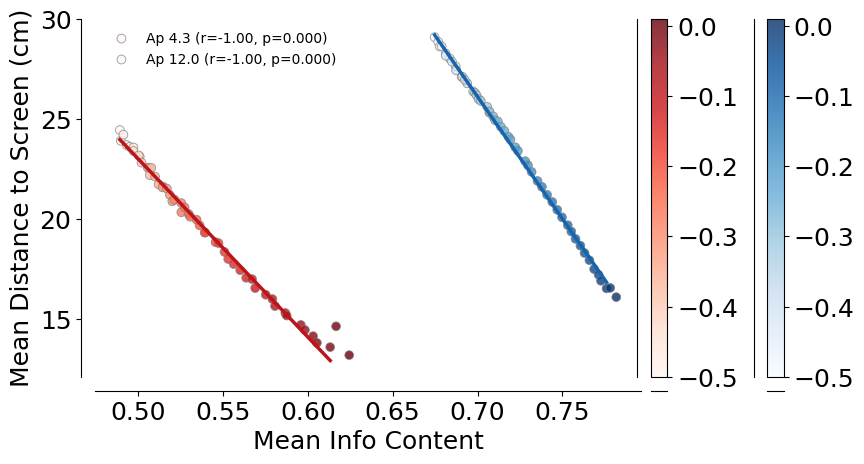

In [56]:
from scipy.stats import pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Correlation between velocity and info gain (binned means)
vel_binned = binned_by_metric["distance_to_screen"]
info_binned = binned_by_metric["info_gain"]
corr_df = vel_binned.merge(
    info_binned,
    on=["aperture", "t_bin"],
    suffixes=("_vel", "_info"),
)

# Define your correlation window here
corr_window = (-0.5, 0.0)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
divider = make_axes_locatable(ax)
apertures_sorted = sorted(corr_df.aperture.unique())[:2]

cmap_by_ap = {
    apertures_sorted[0]: "Reds",
    apertures_sorted[1]: "Blues",
}

for i, ap in enumerate(apertures_sorted):
    # 1. Full data for the scatter plot
    ap_df = corr_df[corr_df.aperture == ap].dropna(subset=["mean_info", "mean_vel"])
    if ap_df.empty:
        continue

    # 2. Subset data for Pearson Correlation and Regression
    mask = (ap_df.t_bin >= corr_window[0]) & (ap_df.t_bin <= corr_window[1])
    stat_df = ap_df[mask]
    
    label_str = f"Ap {ap}"
    if not stat_df.empty:
        r_coeff, p_val = pearsonr(stat_df["mean_info"], stat_df["mean_vel"])
        label_str += f" (r={r_coeff:.2f}, p={p_val:.3f})"
        
        # Plot regression line ONLY for the correlation window
        slope, intercept = np.polyfit(stat_df["mean_info"], stat_df["mean_vel"], 1)
        x_range = np.linspace(stat_df["mean_info"].min(), stat_df["mean_info"].max(), 10)
        ax.plot(x_range, slope * x_range + intercept, 
                color=plt.get_cmap(cmap_by_ap[ap])(0.8), linewidth=2.5, zorder=5)

    # 3. Plot ALL scatter points
    sc = ax.scatter(
        ap_df["mean_info"],
        ap_df["mean_vel"],
        c=ap_df["t_bin"],
        cmap=cmap_by_ap[ap],
        s=40,
        edgecolors="grey",
        linewidths=0.6,
        label=label_str,
        alpha=0.8
    )

    # 4. Handle Colorbars
    cax = divider.append_axes("right", size="3%", pad=0.1 + (i * 0.9))
    cbar = fig.colorbar(sc, cax=cax, shrink=True)

ax.set_xlabel("Mean Info Content")
ax.set_ylabel("Mean Distance to Screen (cm)")
ax.legend(frameon=False, bbox_to_anchor=(0, 1), loc='upper left')
sns.despine(offset=10)
plt.tight_layout(pad=2.0)
plt.show()

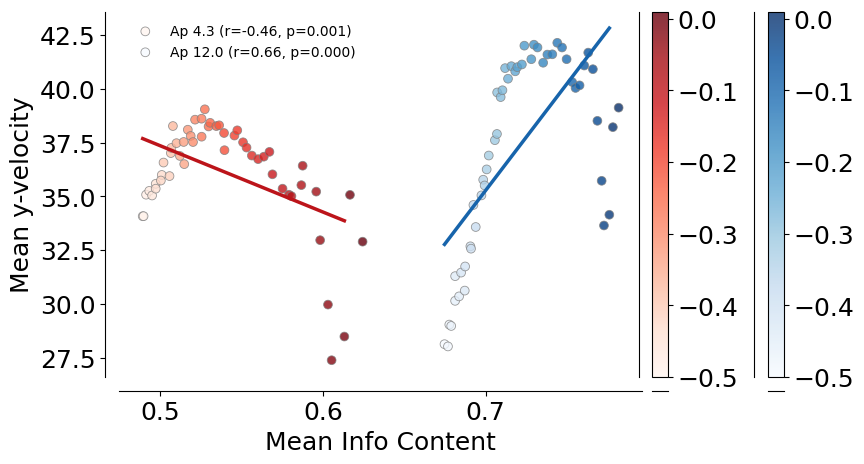

In [57]:
from scipy.stats import pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Correlation between velocity and info gain (binned means)
vel_binned = binned_by_metric["velocity_y"]
info_binned = binned_by_metric["info_gain"]
corr_df = vel_binned.merge(
    info_binned,
    on=["aperture", "t_bin"],
    suffixes=("_vel", "_info"),
)

# Define your correlation window here
corr_window = (-0.5, 0.0)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
divider = make_axes_locatable(ax)
apertures_sorted = sorted(corr_df.aperture.unique())[:2]

cmap_by_ap = {
    apertures_sorted[0]: "Reds",
    apertures_sorted[1]: "Blues",
}

for i, ap in enumerate(apertures_sorted):
    # 1. Full data for the scatter plot
    ap_df = corr_df[corr_df.aperture == ap].dropna(subset=["mean_info", "mean_vel"])
    if ap_df.empty:
        continue

    # 2. Subset data for Pearson Correlation and Regression
    mask = (ap_df.t_bin >= corr_window[0]) & (ap_df.t_bin <= corr_window[1])
    stat_df = ap_df[mask]
    
    label_str = f"Ap {ap}"
    if not stat_df.empty:
        r_coeff, p_val = pearsonr(stat_df["mean_info"], stat_df["mean_vel"])
        label_str += f" (r={r_coeff:.2f}, p={p_val:.3f})"
        
        # Plot regression line ONLY for the correlation window
        slope, intercept = np.polyfit(stat_df["mean_info"], stat_df["mean_vel"], 1)
        x_range = np.linspace(stat_df["mean_info"].min(), stat_df["mean_info"].max(), 10)
        ax.plot(x_range, slope * x_range + intercept, 
                color=plt.get_cmap(cmap_by_ap[ap])(0.8), linewidth=2.5, zorder=5)

    # 3. Plot ALL scatter points
    sc = ax.scatter(
        ap_df["mean_info"],
        ap_df["mean_vel"],
        c=ap_df["t_bin"],
        cmap=cmap_by_ap[ap],
        s=40,
        edgecolors="grey",
        linewidths=0.6,
        label=label_str,
        alpha=0.8
    )

    # 4. Handle Colorbars
    cax = divider.append_axes("right", size="3%", pad=0.1 + (i * 0.9))
    cbar = fig.colorbar(sc, cax=cax, shrink=True)

ax.set_xlabel("Mean Info Content")
ax.set_ylabel("Mean y-velocity")
ax.legend(frameon=False, bbox_to_anchor=(0, 1), loc='upper left')
sns.despine(offset=10)
plt.tight_layout(pad=2.0)
plt.show()

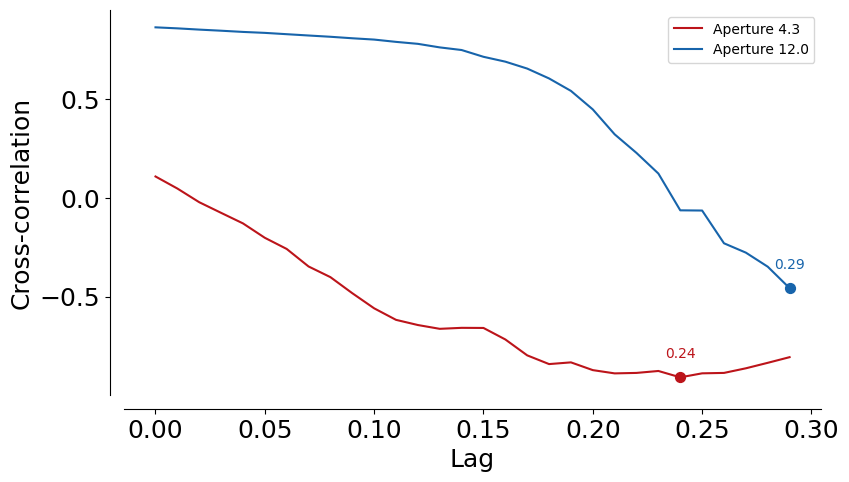

In [58]:
actual_bin_width = 0.01 
lags = np.arange(0, 0.3, actual_bin_width)
lag_steps = np.round(lags / actual_bin_width).astype(int)

analysis_df = corr_df[(corr_df.t_bin >= -0.5) & (corr_df.t_bin <= -0.05)]

cross_corrs = {}
for ap in apertures_sorted:
    ap_df = analysis_df[analysis_df.aperture == ap].dropna(subset=["mean_info", "mean_vel"])
    if ap_df.empty:
        continue

    info_series = ap_df["mean_info"].values
    vel_series = ap_df["mean_vel"].values

    cross_corr = []
    for step in lag_steps:
        if step > 0:
            # Info is the "Cause" (starts at 0)
            # Vel is the "Effect" (starts at 'step' delay)
            x = info_series[:-step]
            y = vel_series[step:]
        else:
            x = info_series
            y = vel_series

        if len(x) < 2 or len(y) < 2:
            cross_corr.append(np.nan)
        else:
            cross_corr.append(np.corrcoef(x, y)[0, 1])

    cross_corrs[ap] = cross_corr

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
for ap in apertures_sorted:
    if ap in cross_corrs:
        ax.plot(lags, cross_corrs[ap], label=f"Aperture {ap}", color=plt.get_cmap(cmap_by_ap[ap])(0.8))

# Add a dot at min correlation for each aperture and display the lag value
for ap in apertures_sorted:
    if ap in cross_corrs:
        min_idx = np.nanargmin(cross_corrs[ap])
        ax.scatter(lags[min_idx], cross_corrs[ap][min_idx], color=plt.get_cmap(cmap_by_ap[ap])(0.8), s=50, zorder=10)
        ax.text(lags[min_idx], cross_corrs[ap][min_idx] + 0.1, f"{lags[min_idx]:.2f}", 
                color=plt.get_cmap(cmap_by_ap[ap])(0.8), fontsize=10, ha='center')
ax.set_xlabel("Lag")
ax.set_ylabel("Cross-correlation")
ax.legend()
sns.despine(offset=10)
plt.show()

Levene variance test within aperture 4.3: stat=9.568, p=0.00627
Levene variance test within aperture 12.0: stat=9.635, p=0.00612
IQR within aperture 4.3: CV(info)=0.037, CV(distance)=0.123
IQR within aperture 12.0: CV(info)=0.016, CV(distance)=0.077


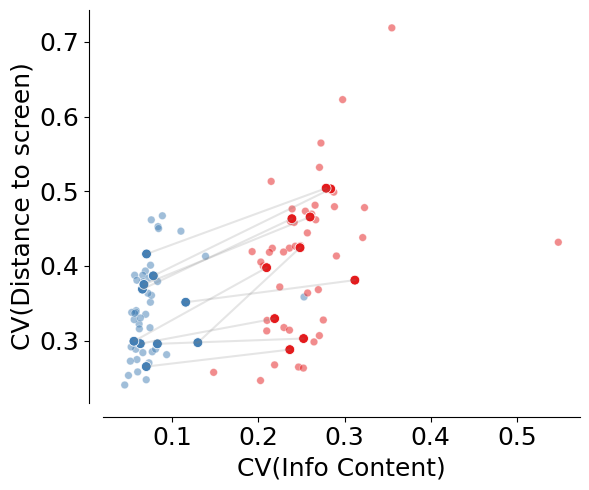

In [59]:
# the CV of Distance from the screen at decision point vs CV of information gain at decision point

dp_info_cv = decision_points.groupby(["mouse_name", "dataset", "aperture"])[["info_gain", "distance_to_screen"]].agg(lambda x: x.std() / x.mean()).reset_index()
dp_info_cv_mean = dp_info_cv.groupby(["mouse_name", "aperture"])[["info_gain", "distance_to_screen"]].mean().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.scatterplot(
    data=dp_info_cv,
    x="info_gain",
    y="distance_to_screen",
    hue="aperture",
    palette=plotting.colors_aperture,
    s=30,
    alpha=0.5,
)

sns.scatterplot(
    data=dp_info_cv_mean,
    x="info_gain",
    y="distance_to_screen",
    hue="aperture",
    palette=plotting.colors_aperture,
    s=50,
)

# Link mouse across apertures
sns.lineplot(
    data=dp_info_cv_mean,
    x="info_gain",
    y="distance_to_screen",
    units="mouse_name",
    estimator=None,
    color="gray",
    alpha=0.2,
    legend=False,
    zorder=1
)

# Add Levene's test to compare spread between info content vs distance (within each aperture)
for ap in sorted(dp_info_cv_mean["aperture"].unique())[:2]:
    info_vals = dp_info_cv_mean[dp_info_cv_mean.aperture == ap]["info_gain"].dropna()
    dist_vals = dp_info_cv_mean[dp_info_cv_mean.aperture == ap]["distance_to_screen"].dropna()
    if len(info_vals) < 2 or len(dist_vals) < 2:
        print(f"Levene test within aperture {ap}: insufficient data")
        continue
    stat, p_val = stats.levene(info_vals, dist_vals, center="median")
    print(f"Levene variance test within aperture {ap}: stat={stat:.3f}, p={p_val:.3g}")

for ap in sorted(dp_info_cv_mean["aperture"].unique())[:2]:
    info_vals = dp_info_cv_mean[dp_info_cv_mean.aperture == ap]["info_gain"].dropna()
    dist_vals = dp_info_cv_mean[dp_info_cv_mean.aperture == ap]["distance_to_screen"].dropna()
    info_iqr = info_vals.quantile(0.75) - info_vals.quantile(0.25) if len(info_vals) else np.nan
    dist_iqr = dist_vals.quantile(0.75) - dist_vals.quantile(0.25) if len(dist_vals) else np.nan
    print(f"IQR within aperture {ap}: CV(info)={info_iqr:.3f}, CV(distance)={dist_iqr:.3f}")


plt.legend([], [], frameon=False)
ax.set_xlabel("CV(Info Content)")
ax.set_ylabel("CV(Distance to screen)")
sns.despine(offset=10)
plt.tight_layout()

In [60]:
interpolated_df["date"] = pd.to_datetime(interpolated_df["dataset"].str.split("_").str[1])
interpolated_df.sort_values(by=["mouse_name", "date"], inplace=True)

In [61]:
import copy
temp_interpolated_df = copy.deepcopy(interpolated_df)

In [62]:
temp_interpolated_df = temp_interpolated_df[temp_interpolated_df.mouse_name != "J731"]
temp_interpolated_df["y"] = temp_interpolated_df["y"]
first_datasets = temp_interpolated_df[(temp_interpolated_df.trial == 20) & (temp_interpolated_df.trial_length == 0.0)].groupby('mouse_name').first()["dataset"]
second_datasets = temp_interpolated_df[(temp_interpolated_df.trial == 20) & (temp_interpolated_df.trial_length == 0.0)].groupby('mouse_name').apply(lambda x: x.iloc[1])["dataset"]

In [63]:
# only the first session for each mouse
first_session_df = interpolated_df[interpolated_df.dataset.isin(first_datasets)]
second_session_df = interpolated_df[interpolated_df.dataset.isin(second_datasets)]

# We remove J731 because there's only one session for this mouse
first_session_df = first_session_df[~first_session_df.mouse_name.isin(["J731"])]
second_session_df = second_session_df[~second_session_df.mouse_name.isin(["J731"])]


### Information contained at decision point per condition

In [64]:
def get_info_at_position(info_matrix, position):
    # Assuming info_matrix is a 2D numpy array and position is a tuple (x, y)
    x, y = position
    # Convert position to matrix indices
    x_idx = int(x + 27)
    y_idx = int(y + 27)
    
    # but the matrix is 52x42 so the positions need to be scaled down
    x_idx_norm = int(x_idx * (51 / 54))
    y_idx_norm = int(y_idx * (41 / 54))
    
    y_idx_norm = info_matrix.shape[0] - 1 - y_idx_norm
    return info_matrix[y_idx_norm, x_idx_norm]  # Note: y comes first in matrix indexing

In [65]:
# Compute information for each timepoint in interpolated_df
interpolated_df["info_gain"] = interpolated_df.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [66]:
decision_points.dropna(subset=["x", "y"], inplace=True)
decision_points["info_gain"] = decision_points.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [67]:
interpolated_df = interpolated_df.sort_values(by=["mouse_name", "dataset"])
#interpolated_df["session_idx"] = interpolated_df.groupby(["mouse_name").cumcount() + 1

session_map = interpolated_df.groupby(["mouse_name", "dataset"]).ngroup()
interpolated_df["session_idx"] = interpolated_df.groupby("mouse_name")["dataset"].transform(lambda x: x.map({val: i+1 for i, val in enumerate(x.unique())}))

In [68]:
decision_points["trial_length"] = decision_points["trial_length"].astype(float)

In [69]:
# for each trial, get the initial position
initial_positions = interpolated_df.groupby(
    ["mouse_name", "dataset", "aperture", "trial"], as_index=False
).first()[["mouse_name", "dataset", "aperture", "trial", "x", "y"]]

# Get info at initial position
initial_positions["info_gain"] = initial_positions.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [70]:
# Decision point information available
info_at_decision_per_session = decision_points.groupby(["mouse_name", "aperture"], as_index=False).mean(numeric_only=True)

info_at_decision_per_session = info_at_decision_per_session.rename(columns={None: "info_gain"})
info_at_decision_per_session["count"] = info_at_decision_per_session["info_gain"]
info_at_decision_per_session = pd.DataFrame(info_at_decision_per_session.reset_index())
info_at_decision_per_session.aperture = info_at_decision_per_session.aperture.astype(str)

# Initial position information available
initial_positions = initial_positions.groupby(["mouse_name", "dataset", "aperture"], as_index=False)["info_gain"].mean()
initial_positions["count"] = initial_positions["info_gain"]
initial_positions = pd.DataFrame(initial_positions.reset_index())
initial_positions.aperture = initial_positions.aperture.astype(float).round(2).astype(str)

# Difference in information available
information_difference = info_at_decision_per_session.copy()
information_difference["info_gain"] = information_difference["info_gain"] - initial_positions["info_gain"]
information_difference["count"] = information_difference["info_gain"]
information_difference = pd.DataFrame(information_difference.reset_index())
information_difference.aperture = information_difference.aperture.astype(float).round(2).astype(str)

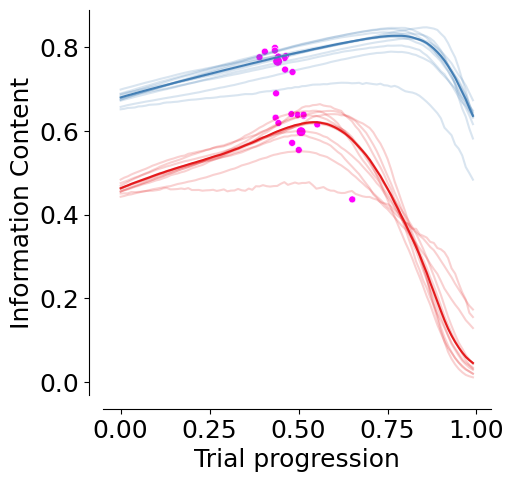

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = interpolated_df[(interpolated_df.dataset == session_to_plot)]


group = group[group.trial.isin(np.array(trials))]
for mouse in interpolated_df.mouse_name.unique():
    sns.lineplot(
        data=interpolated_df[(interpolated_df.mouse_name==mouse)],
        x="trial_length",
        y="info_gain",
        hue="aperture",
        palette=plotting.colors_aperture,
        errorbar=None,
        ax=ax,
        alpha=0.2
    )
    
sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="info_gain",
        hue="aperture",
        palette=plotting.colors_aperture,
        errorbar="se",
        ax=ax
    )

# Add decision points
mean_decision_points = decision_points.groupby(["mouse_name", "aperture"], as_index=False).mean(numeric_only=True)
sns.scatterplot(
    data=info_at_decision_per_session,
    x="trial_length",
    y="info_gain",
    hue="aperture",
    palette=["magenta", "magenta"],
    ax=ax,
)

sns.scatterplot(
    data=mean_decision_points.groupby("aperture", as_index=False).mean(numeric_only=True),
    x="trial_length",
    y="info_gain",
    hue="aperture",
    palette=["magenta", "magenta"],
    s=50,
    ax=ax,
)

ax.set_ylabel("Information Content")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)


Information at Initiation
12.0-4.3: TtestResult(statistic=111.21926360212098, pvalue=1.5304876028897507e-54, df=43)
Information at Decision
12.0-4.3: TtestResult(statistic=15.795296952723417, pvalue=7.196872206437264e-08, df=9)
Information Difference
12.0-4.3: TtestResult(statistic=-4.1905137278913545, pvalue=0.002339335522496334, df=9)


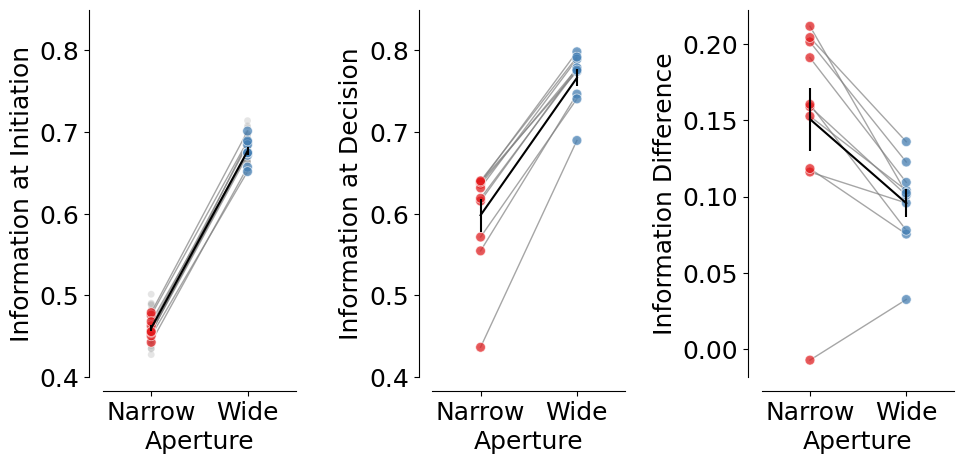

In [72]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))


plotting._plot_bar_counts(
    counts=initial_positions,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()
ax[0].set_ylabel("Information at Initiation")
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
ax[0].set_xlabel("Aperture")
ax[0].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

plotting._plot_bar_counts(
    counts=info_at_decision_per_session,
    label_x="aperture",
    alpha=0.2,
    ax=ax[1],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[1].invert_xaxis()
ax[1].set_ylabel("Information at Decision")
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
ax[1].set_xlabel("Aperture")
ax[1].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[1])

plotting._plot_bar_counts(
    counts=information_difference,
    label_x="aperture",
    alpha=0.2,
    ax=ax[2],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[2].invert_xaxis()
ax[2].set_ylabel("Information Difference")
ax[2].set_xlim(-0.5, 1.5)
ax[2].set_xticks([0, 1], ["Narrow", "Wide"])
ax[2].set_xlabel("Aperture")
ax[2].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[2])

ax[0].set_ylim(0.4, 0.85)
ax[1].set_ylim(0.4, 0.85)
#ax[2].set_ylim(0, 0.35)

plt.tight_layout(pad=2)
plt.savefig(
    save_fig_path + "figure4_information_quantification.svg",
    transparent=True,
)


for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    for i in info.aperture.unique():
        for j in info.aperture.unique():
            if i < j:
                stat = stats.ttest_rel(
                    info[info["aperture"] == i]["count"],
                    info[info["aperture"] == j]["count"],
                )
                print(f"{i}-{j}: {stat}")
                


In [73]:
# Get mean + sem for all 
for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    # round to 2 decimals
    print(info.groupby("aperture")["count"].mean().round(3))
    print(info.groupby("aperture")["count"].sem().round(3))

Information at Initiation
aperture
12.0    0.680
4.3     0.461
Name: count, dtype: float64
aperture
12.0    0.002
4.3     0.003
Name: count, dtype: float64
Information at Decision
aperture
12.0    0.766
4.3     0.598
Name: count, dtype: float64
aperture
12.0    0.01
4.3     0.02
Name: count, dtype: float64
Information Difference
aperture
12.0    0.096
4.3     0.151
Name: count, dtype: float64
aperture
12.0    0.009
4.3     0.021
Name: count, dtype: float64


### Distance to screen of the decision points per condition

In [74]:
decision_points["y"] = decision_points["y"].astype(float)

mean: 13.954705127331682 +/- 0.4271650330662339
12.0-4.3: TtestResult(statistic=-5.98797408637866, pvalue=3.806668315219049e-07, df=43)
 mean difference:  3.4510876320877806
mean: 10.503617495243901 +/- 0.36650869516925794


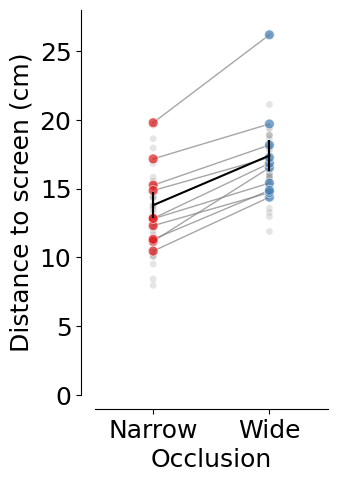

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts, stats_mean = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

# plt.savefig(
#     save_fig_path + "figure4_decision_points_distance.svg",
#     transparent=True,
# )

In [76]:
decision_points["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

mean: 13.954705127331685 +/- 0.4271650330662339
12.0-4.3: TtestResult(statistic=-9.682232357625434, pvalue=2.2791393825149633e-12, df=43)
 mean difference:  3.4510876320877824
mean: 10.503617495243903 +/- 0.36650869516925794


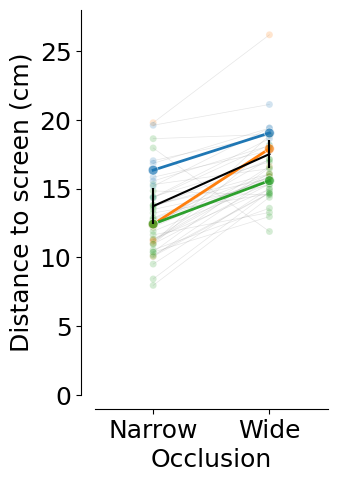

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_mean = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_lab=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure4_decision_points_distance_per_lab.svg",
    transparent=True,
)

In [78]:
decision_points_stats = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
anova_rm = AnovaRM(decision_points_stats, depvar="y", subject="dataset", within=["aperture"])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 93.7456 1.0000 43.0000 0.0000



In [79]:
decision_points.groupby("aperture").y.mean(), decision_points.groupby("aperture").y.sem()

(aperture
 4.3     14.195101
 12.0    10.757179
 Name: y, dtype: float64,
 aperture
 4.3     0.087053
 12.0    0.086991
 Name: y, dtype: float64)

### Relate decision point position to reward rate

In [80]:
mean_decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)

In [81]:
# get first and last quintile of decision points, per dataset
first_quintiles = mean_decision_points[mean_decision_points.aperture==4.3]['y'].quantile(0.2)
last_quintiles = mean_decision_points[mean_decision_points.aperture==4.3]['y'].quantile(0.8)

# get the dfs before q1 and after q3
before_q1 = mean_decision_points[(mean_decision_points.aperture==4.3) & (mean_decision_points['y'] < first_quintiles)] #furthest from screen
after_q3 = mean_decision_points[(mean_decision_points.aperture==4.3) & (mean_decision_points['y'] > last_quintiles)] #closest to screen

# add column for mouse name
before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]

/tmp/ipykernel_1603715/2084882542.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
/tmp/ipykernel_1603715/2084882542.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]


In [82]:
before_q1.mouse_name.unique(), after_q3.mouse_name.unique()

(array(['31726', '31728', 'J731', 'Lemming', 'Pheasant'], dtype=object),
 array(['J729', 'Jacana', 'Lemming', 'Nightingale', 'Oribi'], dtype=object))

In [83]:
before_q1.dataset.nunique(), after_q3.dataset.nunique()

(9, 9)

In [84]:
# get reward rate
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

4.3: mean=0.726 ± 0.019
12.0-4.3: TtestResult(statistic=5.843027235190215, pvalue=2.4960716051221573e-05, df=16)
12.0: mean=0.867 ± 0.013
4.3: mean=0.795 ± 0.019
12.0-4.3: TtestResult(statistic=4.4700285565646976, pvalue=0.00015984419487565023, df=24)
12.0: mean=0.884 ± 0.011


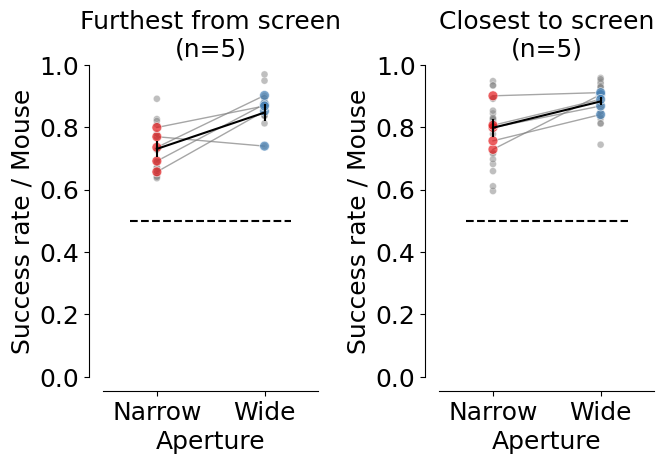

In [85]:
# plot the lower and upper quartile reward rate for only the sessions in the quartiles
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

counts = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(before_q1.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[0].set_ylim(0, 1.0)
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xlabel("Aperture")
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[0])
ax[0].legend([], [], frameon=False)
ax[0].set_title(f"Furthest from screen\n(n={counts.mouse_name.nunique()})")

counts2 = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(after_q3.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[1],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[1].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[1].set_ylim(0, 1.0)
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylabel("Success rate / Mouse")
ax[1].set_xlabel("Aperture")
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[1])
ax[1].legend([], [], frameon=False)
ax[1].set_title(f"Closest to screen\n(n={counts2.mouse_name.nunique()})")
plt.savefig(save_fig_path + "figure4_trial_reward_groups.svg", transparent=True)

plt.tight_layout(pad=2)

In [86]:
# stats difference between groups
stats_res = ttest_ind(
    counts[counts.aperture=="4.3"]["count"],
    counts2[counts2.aperture=="4.3"]["count"]
)
print("narrow", stats_res)

stats_res = ttest_ind(
    counts[counts.aperture=="12.0"]["count"],
    counts2[counts2.aperture=="12.0"]["count"]
)
print("wide", stats_res)

narrow TtestResult(statistic=-2.469988028251627, pvalue=0.017874764025115095, df=40.0)
wide TtestResult(statistic=-0.9946369950078111, pvalue=0.32589195933694937, df=40.0)


## Investigating first test session

In [87]:
# and for decision points
first_decision_points = decision_points[decision_points.dataset.isin(first_datasets)]
second_decision_points = decision_points[decision_points.dataset.isin(second_datasets)]

first_decision_points = first_decision_points[~first_decision_points.mouse_name.isin(["J731"])]
second_decision_points = second_decision_points[~second_decision_points.mouse_name.isin(["J731"])]

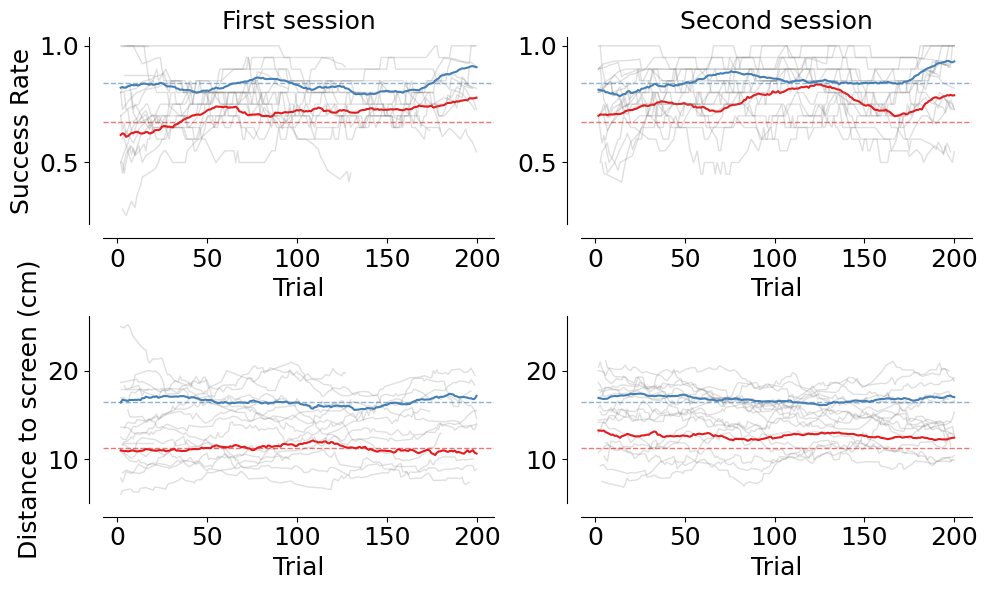

In [88]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))#, sharex=True)

# Link Y-axis for Row 0
ax[0, 1].sharey(ax[0, 0])

# Link Y-axis for Row 1
ax[1, 1].sharey(ax[1, 0])


window_size = 20
n_trials = 200

for aperture, color in zip([4.3, 12], plotting.colors_aperture):
    plotting.plot_mouse_trial_lineplot(first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)], 
                                       "trial_rewarded", 
                                    ax=ax[0][0],
                                    rolling_window=window_size,
                                    color_mean=color,
    normalize=False)
    plotting.plot_mouse_trial_lineplot(second_decision_points[(second_decision_points.aperture==aperture) & (second_decision_points.trial <= n_trials)], 
                                       "trial_rewarded",
                                    ax=ax[0][1],
                                    rolling_window=window_size,
                                    normalize_df=first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)],
                                    color_mean=color,
    normalize=False)

ax[0][0].set_title("First session")
ax[0][1].set_title("Second session")

# Mirror the first row, swapping left/right positions
for aperture, color in zip([4.3, 12], plotting.colors_aperture):
    plotting.plot_mouse_trial_lineplot(first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)], "distance_to_screen",
                                    ax=ax[1][0],
                                    rolling_window=window_size,
                                    color_mean=color,
    normalize=False)
    plotting.plot_mouse_trial_lineplot(second_decision_points[(second_decision_points.aperture==aperture) & (second_decision_points.trial <= n_trials)], "distance_to_screen",
                                    ax=ax[1][1],
                                    rolling_window=window_size,
                                    normalize_df=first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)],
                                    color_mean=color,
    normalize=False)

ax[1][0].set_title("")
ax[1][1].set_title("")

ax[0][1].set_ylabel("")
ax[1][1].set_ylabel("")
ax[0][0].set_ylabel("Success Rate")
ax[1][0].set_ylabel("Distance to screen (cm)")

for ax in ax.flatten():
    sns.despine(offset=10, ax=ax)
    
plt.tight_layout()

/app/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/app/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/app/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/app/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


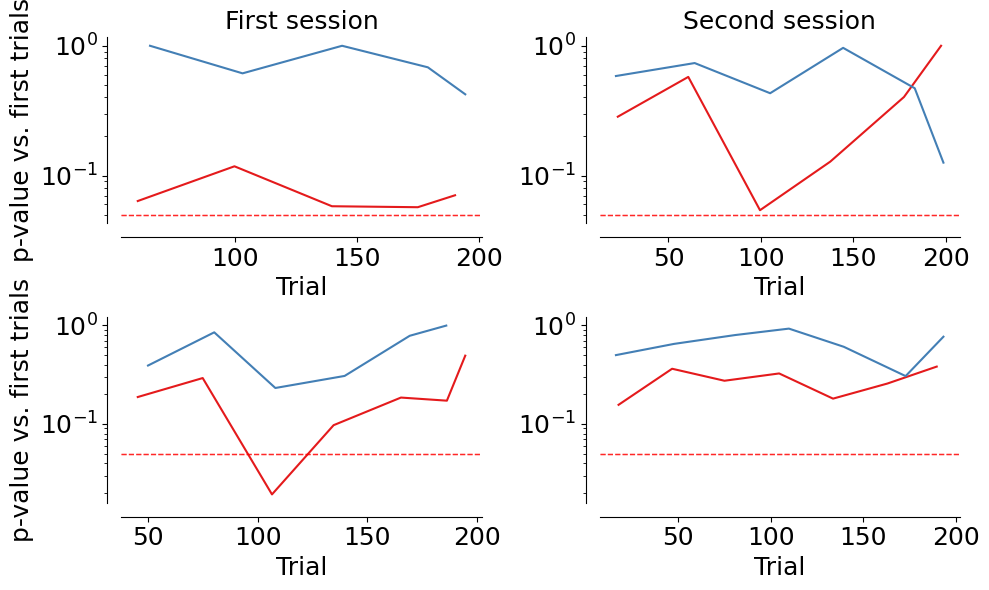

In [89]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))#, sharex=True)

# Link Y-axis for Row 0
ax[0, 1].sharey(ax[0, 0])

# Link Y-axis for Row 1
ax[1, 1].sharey(ax[1, 0])

window_size = 20
n_trials = 200

for aperture, color in zip([4.3, 12], plotting.colors_aperture):
    _ = plotting.plot_pvalue_vs_baseline_by_bin(
            df=first_session_df[(first_session_df.aperture==aperture) & (first_session_df.trial <= n_trials)],
            label="trial_rewarded",
            rolling_window=window_size,
            ax=ax[0][0],
            session_col="dataset",
            color=color,
        )
    _ = plotting.plot_pvalue_vs_baseline_by_bin(
        df=second_session_df[(second_session_df.aperture==aperture) & (second_session_df.trial <= n_trials)],
        label="trial_rewarded",
        rolling_window=window_size,
        session_col="mouse_name",
        ax=ax[0][1],
        baseline_df=first_session_df[(first_session_df.aperture==aperture) & (first_session_df.trial <= n_trials)],
        color=color,
    )

ax[0][0].set_title("First session")
ax[0][1].set_title("Second session")

# Mirror the first row, swapping left/right positions
for aperture, color in zip([4.3, 12], plotting.colors_aperture):
    _ = plotting.plot_pvalue_vs_baseline_by_bin(
        df=first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)],
        label="distance_to_screen",
        rolling_window=15,
        ax=ax[1][0],
        session_col="mouse_name",
        color=color,
    )
    _ = plotting.plot_pvalue_vs_baseline_by_bin(
        df=second_decision_points[(second_decision_points.aperture==aperture) & (second_decision_points.trial <= n_trials)],
        label="distance_to_screen",
        rolling_window=15,
        session_col="mouse_name",
        color=color,
        ax=ax[1][1],
        baseline_df = first_decision_points[(first_decision_points.aperture==aperture) & (first_decision_points.trial <= n_trials)],
    )

ax[1][0].set_title("")
ax[1][1].set_title("")

ax[0][1].set_ylabel("")
ax[1][1].set_ylabel("")
ax[0][0].set_ylabel("p-value vs. first trials")
ax[1][0].set_ylabel("p-value vs. first trials")

for ax in ax.flatten():
    ax.set_yscale("log")
    sns.despine(offset=10, ax=ax)
    

plt.tight_layout()

## Decision point distance to screen vs. reward rate across successful and less successful sessions
Including sessions with the narrow-wide difference in reward rate > 0.25

In [90]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False,
                                                        consider_reward_drop=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [91]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-05_1
31728_2025-03-06_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
J731_2024-12-09_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


In [92]:
interpolated_df.dataset.nunique(), interpolated_df.mouse_name.nunique()

(46, 10)

In [93]:
model_labels, clean_labels, label_set_name = (
        LabelSet.Member * Label * LabelSet & f"label_set_id='8'").fetch(
            "label_key", "clean_name", "label_set_name")

In [94]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

In [95]:
decision_points = regression.find_decision_point(df_model, 
                                                 threshold_uncertainty=0.2)

Aperture 4.3: r=-0.7057843864945809, p=0.022567528924541
Aperture 12.0: r=-0.266999421524306, p=0.4558250085749076


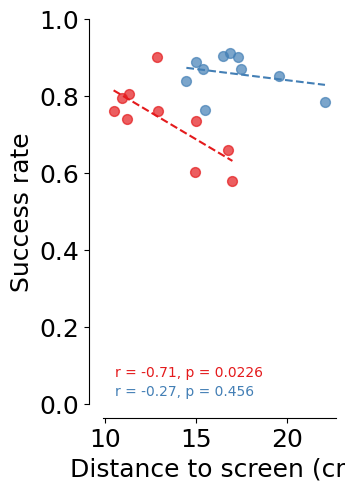

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

for aperture, color, ypos in zip(decision_points.sort_values("aperture").aperture.unique(), 
                                     plotting.colors_aperture,
                                     [0.10, 0.05]):
    x = abs(decision_points[decision_points.aperture==aperture].groupby(
        "mouse_name")["y"].mean().values - 27)
    y = trial_df[(trial_df.aperture==aperture)].groupby(
        "mouse_name")["trial_rewarded"].mean().values


    # scatter
    ax.scatter(
        x, y,
        color=color,
        alpha=0.7,
        s=50
    )

    # regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color=color, linestyle="--")
    
    print(f"Aperture {aperture}: r={r_value}, p={p_value}")

    # annotate correlation
    ax.text(
        0.05, ypos,
        f"r = {r_value:.2f}, p = {p_value:.3g}",
        transform=ax.transAxes,
        va="top", ha="left",
        color=color
    )

    ax.set_xlabel("Distance to screen (cm)")
    ax.set_ylabel("Success rate")
    ax.set_ylim(0, 1.0)
    sns.despine(offset=10, ax=ax)

plt.savefig(save_fig_path + "figure4_decision_point_vs_performance.svg", transparent=True)